# __Trực quan hoá và Phân tích Dữ liệu__

## **1. Tổng quan**

### Bối cảnh chung: 

__Hiện tại hệ thống đang sở hữu một hệ sinh thái dữ liệu thương mại điện tử toàn diện, được chia thành 4 nhóm chính:__

_Dữ liệu nền tảng (*Master Data - 4 file*): Bao gồm __products__, **customers**, **promotions** và **geography**. Đây là khung tham chiếu về danh mục sản phẩm, chân dung khách hàng, các chiến dịch ưu đãi và phân vùng địa lý.

_Dữ liệu giao dịch (*Transaction Data - 6 file*): Theo dõi trọn vẹn vòng đời đơn hàng thông qua **orders**, **order_items** (chi tiết sản phẩm), **payments** (phương thức thanh toán), **shipments** (vận chuyển), cùng với các phản hồi sau mua hàng như **returns** (hàng trả lại) và **reviews** (đánh giá từ khách hàng).

_Dữ liệu vận hành & Lưu lượng (*Operational Data - 2 file*): Ghi lại biến động tồn kho hàng tháng (**inventory**) và hành vi truy cập của người dùng trên website (**web_traffic**), giúp kết nối giữa nhu cầu thị trường và khả năng đáp ứng của kho vận.

_Dữ liệu phân tích & Dự báo (*Analytical Data - 2 file*): Gồm dữ liệu doanh thu lịch sử (**sales**) và tệp mẫu (**sample_submission**) dùng làm cơ sở để huấn luyện và đánh giá các mô hình dự báo Machine Learning.



### Mục tiêu cuối cùng:
__Tạo ra một dataset Orders chuẩn hoá và duy nhất, đóng vai trò là "trục xương sống" cho bài phân tích bằng cách:__

- Hợp nhất luồng dữ liệu: Kết nối dữ liệu bán hàng với vận hành (tồn kho) và tiếp thị (web traffic) để trả lời câu hỏi về hiệu quả kinh doanh tổng thể.

- Làm sạch và tối ưu: Xử lý triệt để các trạng thái đơn hàng (hủy/trả), tính toán chính xác doanh thu thực tế sau khuyến mãi và tích hợp các chỉ số hài lòng (rating).

- Hướng tới phân tích kê đơn (Prescriptive Analytics): Xây dựng bộ đặc trưng (features) hoàn chỉnh để không chỉ dừng lại ở việc báo cáo "doanh thu bao nhiêu", mà còn đề xuất giải pháp tối ưu hóa lợi nhuận, giảm tỷ lệ hoàn hàng và cải thiện trải nghiệm khách hàng bền vững.

## **2. Data Enginering - Chuẩn hóa toàn bộ những file csv về một file data frame duy nhất**
_**Đây là nhiệm vụ của Thành viên 1: Xử lý dữ liệu**_

#### Nhiệm vụ: 

Thu thập và chuẩn hóa dữ liệu từ các nguồn khác nhau thành một "Single Source of Truth".

### **2.1. Chuẩn hoá và Làm sạch sơ bộ (Data Pre-processing)**

**Trước khi ghép, từng file đơn lẻ phải được "dọn dẹp" để tránh lỗi lan truyền:**

- **Xử lý ID**: Ép kiểu str cho tất cả các cột ID (order_id, product_id, customer_id, promo_id, zip). Xử lý các mã khuyến mãi rỗng (NaN) bằng chuỗi "NONE".

- **Định dạng Thời gian**: Chuyển tất cả cột ngày về datetime64. 

*Lưu ý: Trích xuất thêm các thuộc tính thời gian như: Year, Month, Quarter, DayOfWeek, IsWeekend từ order_date.*

- **Xử lý giá trị thiếu** (Imputation):

    **Cột số lượng/giá**: Kiểm tra giá trị âm hoặc rỗng (thường thay bằng Median hoặc 0 tùy ngữ cảnh).

    **Cột hạng mục (Categorical)**: Thay rỗng bằng "Unknown".



In [1]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ------ 1. LOAD DATA ------
# Đường dẫn thư mục
base_path = "C:/Users/Lenovo/Downloads/datathon-2026-round-1/"

# Định nghĩa các cột cần ép kiểu str để tránh lỗi mixed types và mất số 0 ở đầu
dtype_dict = {
    'promo_id': str, 
    'promo_id_2': str, 
    'zip': str, 
    'order_id': str, 
    'customer_id': str, 
    'product_id': str
}

# Import kèm theo tự động nhận diện ngày tháng 
# --- Master ---
df_products    = pd.read_csv(base_path + "products.csv", dtype=dtype_dict)
df_customers   = pd.read_csv(base_path + "customers.csv", dtype=dtype_dict)
df_promotions  = pd.read_csv(base_path + "promotions.csv", dtype=dtype_dict)
df_geography   = pd.read_csv(base_path + "geography.csv", dtype=dtype_dict)

# --- Transactions ---
df_orders      = pd.read_csv(base_path + "orders.csv", dtype=dtype_dict, parse_dates=['order_date'])
df_order_items = pd.read_csv(base_path + "order_items.csv", dtype=dtype_dict, low_memory=False)
df_payments    = pd.read_csv(base_path + "payments.csv", dtype=dtype_dict)
df_shipments   = pd.read_csv(base_path + "shipments.csv", dtype=dtype_dict, parse_dates=['ship_date', 'delivery_date'])
df_returns     = pd.read_csv(base_path + "returns.csv", dtype=dtype_dict, parse_dates=['return_date'])
df_reviews     = pd.read_csv(base_path + "reviews.csv", dtype=dtype_dict, parse_dates=['review_date'])

# --- Analytical ---
df_sales       = pd.read_csv(base_path + "sales.csv", parse_dates=['Date'])
df_inventory   = pd.read_csv(base_path + "inventory.csv", dtype=dtype_dict, parse_dates=['snapshot_date'])

# --- Operational ---
df_web_traffic = pd.read_csv(base_path + "web_traffic.csv", parse_dates=['date'])
df_sample_submission = pd.read_csv(base_path + "sample_submission.csv", parse_dates=['Date'])

In [3]:
# ------ 2. CHUẨN HOÁ ID ------
# Hàm chuẩn hoá các cột ID
# Mục đích:
# - Ép toàn bộ ID về kiểu string để tránh lỗi khi merge
# - Điền giá trị thiếu (NaN) bằng "NONE" để đồng nhất dữ liệu
def normalize_id(df):
    for col in df.columns:
        # Xác định các cột là ID hoặc zip
        if 'id' in col or col == 'zip':
            df[col] = df[col].fillna("NONE").astype(str)
    return df


# Danh sách tất cả dataframe cần chuẩn hoá ID
dataframes = [
    df_products, df_customers, df_promotions, df_geography,
    df_orders, df_order_items, df_payments, df_shipments,
    df_returns, df_reviews, df_inventory
]


# Áp dụng hàm normalize_id cho từng dataframe
for df in dataframes:
    normalize_id(df)

In [4]:
# ------ 3. XỬ LÝ THỜI GIAN + FEATURE ENGINEERING ------
# Hàm xử lý cột thời gian và tạo thêm các đặc trưng (features)
# Mục đích:
# - Đảm bảo cột thời gian ở dạng datetime
# - Trích xuất các thông tin quan trọng phục vụ phân tích/model
def enrich_time(df, col):
    # Kiểm tra cột thời gian có tồn tại trong dataframe
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')  # chuyển về datetime, lỗi -> NaT

        # Tạo các feature thời gian
        df[col + "_year"]       = df[col].dt.year        # năm
        df[col + "_month"]      = df[col].dt.month       # tháng
        df[col + "_quarter"]    = df[col].dt.quarter     # quý
        df[col + "_dayofweek"]  = df[col].dt.dayofweek   # thứ trong tuần (0=Mon)
        df[col + "_is_weekend"] = df[col].dt.dayofweek.isin([5,6]).astype(int)  # cuối tuần (1=yes)

    return df


# Áp dụng cho dữ liệu orders (cột order_date)
df_orders = enrich_time(df_orders, 'order_date')

In [5]:
# ------ 4. XỬ LÝ GIÁ TRỊ THIẾU ------
# Hàm xử lý missing value cho từng dataframe
# Mục đích:
# - Làm sạch dữ liệu trước khi phân tích/merge
# - Đảm bảo không còn giá trị thiếu gây lỗi model
def handle_missing(df):

    # --- Xử lý cột số (numeric) ---
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        # Chuyển giá trị âm (không hợp lệ) thành NaN
        df.loc[df[col] < 0, col] = np.nan
        
        # Điền giá trị thiếu bằng median
        median = df[col].median()
        df[col] = df[col].fillna(median)

    # --- Xử lý cột dạng category/object/string ---
    cat_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        # Điền giá trị thiếu bằng "Unknown"
        df[col] = df[col].fillna("Unknown")

    return df


# Áp dụng xử lý missing value cho toàn bộ dataframe
for i in range(len(dataframes)):
    dataframes[i] = handle_missing(dataframes[i])

In [6]:
# ------ 5. PREPROCESSING ------
# Mục đích:
# - Kiểm tra nhanh cấu trúc dữ liệu sau bước làm sạch
# - Xem kiểu dữ liệu, số lượng non-null (phát hiện missing)

# - Đảm bảo cột thời gian đã được chuyển về datetime
all_dfs = {
    "Orders": df_orders, 
    "Items": df_order_items, 
    "Returns": df_returns, 
    "Inventory": df_inventory, 
    "Traffic": df_web_traffic
}

for name, df in all_dfs.items():
    print(f"\n===== {name} =====")
    
    # Hiển thị thông tin tổng quan dataframe
    df.info()


===== Orders =====
<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               646945 non-null  str           
 1   order_date             646945 non-null  datetime64[us]
 2   customer_id            646945 non-null  str           
 3   zip                    646945 non-null  str           
 4   order_status           646945 non-null  str           
 5   payment_method         646945 non-null  str           
 6   device_type            646945 non-null  str           
 7   order_source           646945 non-null  str           
 8   order_date_year        646945 non-null  int32         
 9   order_date_month       646945 non-null  int32         
 10  order_date_quarter     646945 non-null  int32         
 11  order_date_dayofweek   646945 non-null  int32         
 12  order_date_is_weekend  646945 non-n

### **2.2 Tổng hợp dữ liệu (Aggregation) trước khi Merge**

**Một số bảng có quan hệ n-1 với đơn hàng, nếu Join trực tiếp sẽ làm tăng số dòng sai lệch:**

- **Payments**: Một order_id có thể thanh toán nhiều lần hoặc bằng nhiều phương thức. Cần groupby('order_id') để tính: Total_Paid, Payment_Count, và lấy phương thức thanh toán chính.

- **Inventory**: Ghép theo product_id và tháng. Cần tạo cột YearMonth ở cả bảng inventory và bảng orders để làm khóa phụ.


In [7]:
# ----- 1. AGGREGATE PAYMENTS -----
# - payments là quan hệ gần 1-1 với order nhưng vẫn gom lại để đảm bảo chắc chắn và tạo feature
df_payments_agg = df_payments.groupby('order_id').agg({
    'payment_value': 'sum',        # tổng tiền thanh toán của đơn hàng
    'payment_method': 'count'      # số lần thanh toán (nếu có nhiều dòng)
}).rename(columns={
    'payment_value': 'Total_Paid',
    'payment_method': 'Payment_Count'
}).reset_index()

# Lấy phương thức thanh toán chính (xuất hiện nhiều nhất)
primary_method = df_payments.groupby(['order_id', 'payment_method']) \
    .size().reset_index(name='count')

primary_method = primary_method.sort_values(
    ['order_id', 'count'], ascending=[True, False]
).drop_duplicates('order_id')

primary_method = primary_method[['order_id', 'payment_method']] \
    .rename(columns={'payment_method': 'Primary_Payment_Method'})

# Ghép vào bảng payment aggregate
df_payments_agg = df_payments_agg.merge(
    primary_method, on='order_id', how='left'
)

In [8]:
# ----- 2. CHUẨN BỊ INVENTORY (THEO THÁNG) -----
# - inventory là snapshot theo tháng (cuối tháng), cần tạo khóa YearMonth để join với orders

# Tạo YearMonth cho orders (từ order_date)
df_orders['YearMonth'] = df_orders['order_date'].dt.to_period('M').astype(str)

# Tạo YearMonth cho inventory (từ snapshot_date)
df_inventory['YearMonth'] = df_inventory['snapshot_date'].dt.to_period('M').astype(str)


In [9]:
#  ----- CHECK BƯỚC 2.2: AGGREGATION THÀNH CÔNG ------
# Mục đích:
# - Xác nhận payments đã được gom đúng theo order_id
# - Kiểm tra inventory đã có khóa YearMonth để join

# 1. KIỂM TRA PAYMENTS_AGG
print("\n===== PAYMENTS AGG =====")
df_payments_agg.info()

# Kiểm tra số dòng có bằng số order_id unique không
print("Số order_id unique:", df_payments['order_id'].nunique())
print("Số dòng sau aggregate:", df_payments_agg.shape[0])

# 2. KIỂM TRA INVENTORY + ORDERS
print("\n===== INVENTORY =====")
df_inventory[['product_id', 'YearMonth']].head()

print("\n===== ORDERS =====")
df_orders[['order_id', 'YearMonth']].head()

# 3. CHECK NHANH KEY JOIN
# Kiểm tra xem có bị thiếu key khi join không (sample)
sample_merge = df_orders[['order_id', 'YearMonth']].merge(
    df_inventory[['product_id', 'YearMonth']],
    on='YearMonth',
    how='left'
)

print("\nSample merge rows:", sample_merge.shape[0])


===== PAYMENTS AGG =====
<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                646945 non-null  str    
 1   Total_Paid              646945 non-null  float64
 2   Payment_Count           646945 non-null  int64  
 3   Primary_Payment_Method  646945 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 19.7 MB
Số order_id unique: 646945
Số dòng sau aggregate: 646945

===== INVENTORY =====

===== ORDERS =====

Sample merge rows: 316436105


### **2.3. Quy trình kết nối (The Master Merge)**

**Thực hiện LEFT JOIN theo thứ tự ưu tiên để giữ nguyên số dòng của bảng chi tiết sản phẩm (order_items làm gốc):**

- Core: **order_items** + **orders** (Key: order_id).

- Product info: + **products** (Key: *product_id*) -> Lấy COGS, Category, Sub-category.

- Customer info: + **customers** (Key: *customer_id*) -> Lấy Gender, Segment, Age.

- Region info: + **geography** (Key: *zip*) -> Lấy City, State, Region.

- Logistics: + **shipments** (Key: *order_id*) -> Lấy ship_date, delivery_date, shipping_fee.

- Post-purchase: * + **returns** (Key: *order_id* & *product_id*) -> Tạo cột is_returned (0/1).

- **reviews** (Key: *order_id* & *product_id*) -> Lấy rating.

**External factors:**

-   **inventory** (Key: *product_id* & *YearMonth*) -> Lấy stock_on_hand, stockout_days.

-    **web_traffic** (Key: *order_date*) -> Lấy sessions, bounce_rate của ngày đó.

In [10]:
# ------ 2.3 MASTER MERGE ------
# Mục đích:
# - Kết nối toàn bộ dữ liệu thành một bảng duy nhất (single source of truth)
# - Sử dụng order_items làm bảng gốc để giữ mức chi tiết sản phẩm
# - Đảm bảo không bị nhân dòng khi merge và dữ liệu phản ánh đúng logic thực tế

In [11]:
# ==============================
# 1. CHUẨN BỊ BẢNG GỐC
# ==============================
# - Sao chép từ order_items
# - Loại bỏ các dòng trùng (order_id, product_id)
# - Chuẩn hóa kiểu dữ liệu cho các khóa chính

df_master = df_order_items.copy()
df_master = df_master.drop_duplicates(subset=['order_id', 'product_id'])

for col in ['order_id', 'product_id']:
    df_master[col] = df_master[col].astype(str)

In [12]:
# ==============================
# 2. CORE: ORDERS
# ==============================
# - Ghép thông tin đơn hàng vào bảng chi tiết
# - Bao gồm: ngày đặt, khách hàng, zip giao hàng, trạng thái, thiết bị, nguồn đơn

df_orders_merge = df_orders[
    ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
].copy()

df_orders_merge = df_orders_merge.rename(columns={
    'zip': 'order_zip',
    'payment_method': 'order_payment_method'
})

df_orders_merge[['order_id','customer_id','order_zip']] = \
    df_orders_merge[['order_id','customer_id','order_zip']].astype(str)

df_master = df_master.merge(df_orders_merge, on='order_id', how='left')

In [13]:
# ==============================
# 3. PRODUCT INFO
# ==============================
# - Bổ sung thông tin sản phẩm
# - Bao gồm: tên, danh mục, phân khúc, size, màu sắc, giá bán và giá vốn

df_products_merge = df_products[
    ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']
].copy()

df_products_merge['product_id'] = df_products_merge['product_id'].astype(str)

df_master = df_master.merge(df_products_merge, on='product_id', how='left')

In [14]:
# ==============================
# 4. CUSTOMER INFO
# ==============================
# - Bổ sung thông tin khách hàng
# - Bao gồm: zip cá nhân, thành phố, ngày đăng ký, giới tính, nhóm tuổi, kênh tiếp cận

df_customers_merge = df_customers[
    ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']
].copy()

df_customers_merge = df_customers_merge.rename(columns={
    'zip': 'customer_zip',
    'city': 'customer_city'
})

df_customers_merge[['customer_id','customer_zip']] = \
    df_customers_merge[['customer_id','customer_zip']].astype(str)

df_master = df_master.merge(df_customers_merge, on='customer_id', how='left')

In [15]:
# ==============================
# 5. REGION INFO
# ==============================
# - Sử dụng zip giao hàng để lấy thông tin địa lý
# - Bao gồm: thành phố, vùng, quận/huyện

df_geo = df_geography[['zip', 'city', 'region', 'district']].copy()

df_geo = df_geo.rename(columns={
    'zip': 'order_zip',
    'city': 'geo_city'
})

df_geo['order_zip'] = df_geo['order_zip'].astype(str)

df_master = df_master.merge(df_geo, on='order_zip', how='left')

In [16]:
# ==============================
# 6. LOGISTICS
# ==============================
# - Gom dữ liệu vận chuyển về mức order để tránh nhân dòng
# - Lấy: ngày gửi sớm nhất, ngày giao muộn nhất và tổng phí vận chuyển

df_shipments_merge = df_shipments.groupby('order_id').agg({
    'ship_date': 'min',
    'delivery_date': 'max',
    'shipping_fee': 'sum'
}).reset_index()

df_shipments_merge['order_id'] = df_shipments_merge['order_id'].astype(str)

df_master = df_master.merge(df_shipments_merge, on='order_id', how='left')

In [17]:
# ==============================
# 7. RETURNS
# ==============================
# - Gom dữ liệu trả hàng theo (order_id, product_id)
# - Tạo thêm cột is_returned để đánh dấu sản phẩm có bị trả hay không

df_returns_merge = df_returns.groupby(['order_id', 'product_id']).agg({
    'return_quantity': 'sum',
    'refund_amount': 'sum',
    'return_date': 'max'
}).reset_index()

df_returns_merge['is_returned'] = 1

df_returns_merge[['order_id','product_id']] = \
    df_returns_merge[['order_id','product_id']].astype(str)

df_master = df_master.merge(df_returns_merge, on=['order_id','product_id'], how='left')

df_master['is_returned'] = df_master['is_returned'].fillna(0).astype(int)


In [18]:
# ==============================
# 8. REVIEWS
# ==============================
# - Gom đánh giá theo (order_id, product_id)
# - Lấy điểm trung bình và ngày đánh giá gần nhất

df_reviews_merge = df_reviews.groupby(['order_id','product_id']).agg({
    'rating': 'mean',
    'review_date': 'max'
}).reset_index()

df_reviews_merge = df_reviews_merge.rename(columns={'rating': 'avg_rating'})

df_reviews_merge[['order_id','product_id']] = \
    df_reviews_merge[['order_id','product_id']].astype(str)

df_master = df_master.merge(df_reviews_merge, on=['order_id','product_id'], how='left')

In [19]:
# ==============================
# 9. INVENTORY
# ==============================
# - Tạo khóa YearMonth từ order_date
# - Ghép tồn kho theo product_id và tháng

df_master['YearMonth'] = pd.to_datetime(df_master['order_date']).dt.to_period('M').astype(str)

if 'YearMonth' not in df_inventory.columns:
    df_inventory['YearMonth'] = pd.to_datetime(df_inventory['snapshot_date']).dt.to_period('M').astype(str)

df_inv = df_inventory[
    ['product_id','YearMonth','stock_on_hand','stockout_days','days_of_supply',
     'fill_rate','stockout_flag','overstock_flag','reorder_flag','sell_through_rate']
].copy()

df_inv['product_id'] = df_inv['product_id'].astype(str)

df_master = df_master.merge(df_inv, on=['product_id','YearMonth'], how='left')


In [20]:
# ==============================
# 10. WEB TRAFFIC
# ==============================
# - Chuẩn hóa về mức ngày
# - Ghép theo ngày đặt hàng để lấy hành vi truy cập

df_web = df_web_traffic.copy()
df_web['date'] = pd.to_datetime(df_web['date']).dt.normalize()

df_web = df_web.groupby('date').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum',
    'page_views': 'sum',
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean'
}).reset_index()

df_master['order_date_only'] = pd.to_datetime(df_master['order_date']).dt.normalize()

df_master = df_master.merge(
    df_web,
    left_on='order_date_only',
    right_on='date',
    how='left'
)

df_master = df_master.drop(columns=['date'])

In [21]:
# ==============================
# 11. XỬ LÝ LOGIC NGHIỆP VỤ
# ==============================
# - Phân bổ phí vận chuyển về từng dòng sản phẩm
# - Xử lý giá trị thiếu của dữ liệu web traffic

items_per_order = df_master.groupby('order_id')['product_id'].transform('count')
df_master['shipping_fee'] = df_master['shipping_fee'] / items_per_order

traffic_cols = ['sessions','unique_visitors','page_views']
df_master[traffic_cols] = df_master[traffic_cols].fillna(0)

rate_cols = ['bounce_rate','avg_session_duration_sec']
df_master[rate_cols] = df_master[rate_cols].fillna(df_master[rate_cols].median())

In [22]:
# ==============================
# 12. HOÀN THIỆN DỮ LIỆU
# ==============================
# - Loại bỏ trùng lần cuối để đảm bảo tính toàn vẹn
# - Chuẩn hóa lại kiểu dữ liệu các khóa chính

df_master = df_master.drop_duplicates(subset=['order_id','product_id'])

for col in ['order_id','product_id','customer_id','order_zip','customer_zip']:
    if col in df_master.columns:
        df_master[col] = df_master[col].astype(str)

<font size="5"> ***Kết quả: một Single Source of Truth*** </font> 

In [23]:
df_master

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,order_zip,...,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,order_date_only,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
0,1,2400,7.0,1138.22,0.0,NONE,NONE,2012-07-04,58578,1109,...,1.0,1.0,0.0,0.2436,2012-07-04,0.0,0.0,0.0,0.00442,208.6
1,2,609,7.0,10166.25,0.0,NONE,NONE,2012-07-04,58621,1330,...,1.0,1.0,0.0,0.2338,2012-07-04,0.0,0.0,0.0,0.00442,208.6
2,3,396,3.0,11220.33,0.0,NONE,NONE,2012-07-04,58811,1473,...,1.0,1.0,0.0,0.2332,2012-07-04,0.0,0.0,0.0,0.00442,208.6
3,4,635,5.0,10639.25,0.0,NONE,NONE,2012-07-04,59453,2360,...,0.0,1.0,0.0,0.2342,2012-07-04,0.0,0.0,0.0,0.00442,208.6
4,6,1935,1.0,1597.84,0.0,NONE,NONE,2012-07-06,57821,2886,...,0.0,1.0,0.0,0.2388,2012-07-06,0.0,0.0,0.0,0.00442,208.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714648,834372,690,8.0,4473.92,0.0,NONE,NONE,2022-12-31,19490,33907,...,1.0,1.0,0.0,0.0162,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7
714649,834377,1995,7.0,5250.79,0.0,NONE,NONE,2022-12-31,73046,37091,...,0.0,1.0,0.0,0.0165,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7
714650,834387,2331,8.0,7389.06,0.0,NONE,NONE,2022-12-31,107723,80516,...,1.0,1.0,0.0,0.0067,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7
714651,834392,1115,5.0,4767.33,0.0,NONE,NONE,2022-12-31,139431,93510,...,0.0,1.0,0.0,0.0519,2022-12-31,21743.0,15512.0,94844.0,0.00394,151.7


In [24]:
# ------ 2.3 CHECK MASTER MERGE THÀNH CÔNG ------
# Mục đích:
# - Kiểm tra bảng master đã được ghép đầy đủ
# - Xác nhận số dòng không bị tăng sai lệch
# - Xem nhanh cấu trúc dữ liệu cuối cùng

print("===== MASTER TABLE =====")
df_master.info()

print("\n===== KÍCH THƯỚC =====")
print("Order Items gốc:", df_order_items.shape)
print("Master sau merge:", df_master.shape)

print("\n===== KIỂM TRA KHÓA CHÍNH =====")
print("Số dòng trùng (order_id, product_id):", df_master.duplicated(subset=['order_id', 'product_id']).sum())

print("\n===== SAMPLE DỮ LIỆU =====")
print(df_master.head(10))

===== MASTER TABLE =====
<class 'pandas.DataFrame'>
RangeIndex: 714653 entries, 0 to 714652
Data columns (total 54 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  714653 non-null  str           
 1   product_id                714653 non-null  str           
 2   quantity                  714653 non-null  float64       
 3   unit_price                714653 non-null  float64       
 4   discount_amount           714653 non-null  float64       
 5   promo_id                  714653 non-null  str           
 6   promo_id_2                714653 non-null  str           
 7   order_date                714653 non-null  datetime64[us]
 8   customer_id               714653 non-null  str           
 9   order_zip                 714653 non-null  str           
 10  order_status              714653 non-null  str           
 11  order_payment_method      714653 non-null  str     

### **2.4: Feature Engineering**

**Đây là bước quyết định độ chính xác của mô hình dự báo Profit:**

***a. Tính toán chỉ số tài chính:***

-   **Gross_Revenue** = **quantity** * **unit_price**

-   **Net_Revenue** = **Gross_Revenue** - **discount_amount**

-   **Total_Cost** = (**quantity** * **COGS**) + **shipping_fee**

-   **Target_Profit** (Biến mục tiêu) = **Net_Revenue** - **Total_Cost** (Trừ thêm refund_amount nếu is_returned == 1).

***b. Chỉ số vận hành:***

-   **Lead_Time**: Số ngày từ **order_date** đến **delivery_date**.

-   **Shipping_Efficiency**: **Lead_Time** / **shipping_fee**.

***c. Chỉ số khách hàng:***

 -   **Customer_Tenure**: Số ngày từ lần mua đầu tiên đến đơn hàng hiện tại.

-   **Order_Frequency**: Tổng số đơn hàng khách đó đã mua tính đến thời điểm hiện tại.

In [25]:
# ------ 2.4 FEATURE ENGINEERING ------
# Mục đích:
# - Tạo các biến đầu vào quan trọng cho mô hình dự báo Profit
# - Bổ sung chỉ số tài chính, vận hành và hành vi khách hàng
# - Đưa dữ liệu về dạng sẵn sàng cho phân tích và modeling

In [26]:
# ==============================
# 1. TÍNH TOÁN CHỈ SỐ TÀI CHÍNH
# ==============================
# - Gross_Revenue: doanh thu gộp trước giảm giá
# - Net_Revenue: doanh thu thực thu sau giảm giá
# - Total_Cost: tổng chi phí gồm giá vốn và phí vận chuyển
# - Target_Profit: lợi nhuận mục tiêu sau khi trừ hoàn tiền nếu có trả hàng

# Đảm bảo các cột số không bị thiếu trước khi tính
df_master['shipping_fee'] = df_master['shipping_fee'].fillna(0)
df_master['refund_amount'] = df_master['refund_amount'].fillna(0)

# Doanh thu gộp
df_master['Gross_Revenue'] = df_master['quantity'] * df_master['unit_price']

# Doanh thu ròng sau giảm giá
df_master['Net_Revenue'] = df_master['Gross_Revenue'] - df_master['discount_amount']

# Tổng chi phí
df_master['Total_Cost'] = (df_master['quantity'] * df_master['cogs']) + df_master['shipping_fee']

# Hoàn tiền chỉ tính nếu đơn có trả hàng
df_master['Refund_Adjustment'] = np.where(df_master['is_returned'] == 1, df_master['refund_amount'], 0)

# Lợi nhuận mục tiêu
df_master['Target_Profit'] = df_master['Net_Revenue'] - df_master['Total_Cost'] - df_master['Refund_Adjustment']

In [27]:
# ==============================
# 2. CHỈ SỐ VẬN HÀNH
# ==============================
# - Lead_Time: số ngày từ lúc đặt đến lúc giao hàng
# - Shipping_Efficiency: thời gian giao hàng trên mỗi đơn vị phí vận chuyển

# Tính Lead_Time nếu có đủ dữ liệu ngày giao hàng
df_master['Lead_Time'] = (df_master['delivery_date'] - df_master['order_date']).dt.days

# Tránh chia cho 0 khi tính hiệu suất vận chuyển
df_master['Shipping_Efficiency'] = df_master['Lead_Time'] / df_master['shipping_fee'].replace(0, np.nan)

In [28]:
# ==============================
# 3. CHỈ SỐ KHÁCH HÀNG
# ==============================
# - Customer_Tenure: số ngày từ lần mua đầu tiên đến đơn hàng hiện tại
# - Order_Frequency: số đơn hàng khách đã mua tính đến thời điểm hiện tại
# Lưu ý: phải tính ở mức order để tránh đếm trùng theo order_items

# Tạo bảng order-level để tính các chỉ số theo đơn hàng
df_customer_order = df_master[['order_id', 'customer_id', 'order_date']].drop_duplicates().copy()

# Sắp xếp theo khách hàng và thời gian đặt hàng
df_customer_order = df_customer_order.sort_values(['customer_id', 'order_date'])

# Lần mua đầu tiên của từng khách hàng
df_customer_order['first_order_date'] = df_customer_order.groupby('customer_id')['order_date'].transform('min')

# Customer_Tenure: số ngày từ lần mua đầu tiên đến đơn hàng hiện tại
df_customer_order['Customer_Tenure'] = (df_customer_order['order_date'] - df_customer_order['first_order_date']).dt.days

# Order_Frequency: thứ tự đơn hàng của khách hàng theo thời gian
df_customer_order['Order_Frequency'] = df_customer_order.groupby('customer_id').cumcount() + 1

# Ghép lại vào bảng master theo order_id
df_master = df_master.merge(
    df_customer_order[['order_id', 'Customer_Tenure', 'Order_Frequency']],
    on='order_id',
    how='left'
)

In [29]:
# ==============================
# 4. DỌN DẸP CUỐI CÙNG
# ==============================
# Loại bỏ cột phụ nếu không cần dùng thêm

df_master = df_master.drop(columns=['Refund_Adjustment', 'first_order_date'], errors='ignore')

<font size="5"> ***Kết quả đầu ra:*** </font>

Nội dung thu được được gọi là:
* **Feature Table** (Bảng đặc trưng)
* **Modeling Dataset** (Tập dữ liệu mô hình)

Mục đích sử dụng:

- Làm đầu vào (input) cho các mô hình **Machine Learning** hoặc phân tích thống kê.


In [30]:
# ------ CHECK FEATURE ENGINEERING ------

# Mục đích:
# - Kiểm tra nhanh các cột mới sau bước 2.4
# - Xem dữ liệu đã sẵn sàng cho phân tích và mô hình hóa hay chưa

print("===== MASTER AFTER FEATURE ENGINEERING =====")
print(df_master[['Gross_Revenue', 'Net_Revenue', 'Total_Cost', 'Target_Profit',
                 'Lead_Time', 'Shipping_Efficiency', 'Customer_Tenure', 'Order_Frequency']].head(10))

print("\n===== INFO =====")
df_master[['Gross_Revenue', 'Net_Revenue', 'Total_Cost', 'Target_Profit',
           'Lead_Time', 'Shipping_Efficiency', 'Customer_Tenure', 'Order_Frequency']].info()

===== MASTER AFTER FEATURE ENGINEERING =====
   Gross_Revenue  Net_Revenue    Total_Cost  Target_Profit  Lead_Time  \
0        7967.54      7967.54   7377.956059     589.583941        7.0   
1       71163.75     71163.75  62916.529616  -44210.789616        6.0   
2       33660.99     33660.99  30275.416767    3385.573233        3.0   
3       53196.25     53196.25  46029.642390    7166.607610        7.0   
4        1597.84      1597.84   1074.486357     523.353643       10.0   
5        9800.94      9800.94   8028.328786    1772.611214        6.0   
6        9617.52      9617.52   8027.233786    1590.286214        5.0   
7        6570.04      6570.04   4195.000429    2375.039571        5.0   
8       32397.12     32397.12  31112.604000    1284.516000        7.0   
9       19886.85     19886.85  13366.921100    6519.928900        7.0   

   Shipping_Efficiency  Customer_Tenure  Order_Frequency  
0             5.109489                0                1  
1             2.307692           

## **3. Data Analytics - Dựa trên file Orders.csv để trực quan hóa các thuộc tính và đưa ra insight**
_**Đây là nhiệm vụ của Thành viên 2: Trực quan hóa và thiết kế biểu đồ**_

#### Nhiệm vụ: 

**Phân tích data và đưa ra những góc nhìn phân tích. Từ những góc nhìn đó, lựa chọn hướng phân tích phù hợp để trực quan hóa và rút ra insight:**



### **3.1 Góc nhìn 1: Hiệu quả doanh thu theo sản phẩm / danh mục / phân khúc**

**Lý do chọn góc nhìn này**: Doanh thu cao chưa chắc đã mang lại lợi nhuận tốt. Việc bóc tách góc nhìn này giúp doanh nghiệp hiểu rõ "dòng tiền thực sự" đang đến từ đâu, sản phẩm nào là "ngôi sao" cần đẩy mạnh, và sản phẩm nào đang tạo doanh thu ảo (bán nhiều nhưng lãi mỏng).

**Câu hỏi cần trả lời -> Những biểu đồ phù hợp***:

- Nhóm sản phẩm nào đang gánh doanh thu nhưng biên lợi nhuận lại quá mỏng? -> **Bar chart** (Trục X: Danh mục, Trục Y: Doanh thu ròng, Màu sắc: Biên lợi nhuận).

- Đâu là nhóm 20% sản phẩm cốt lõi mang lại 80% doanh thu cho công ty? -> **Pareto chart** (Trục X: Mã sản phẩm, Trục Y chính: Doanh thu, Trục Y phụ: % Doanh thu tích lũy).

- Chiến lược giá của chúng ta có đang an toàn không? Có sản phẩm nào rủi ro lỗ? -> **Scatter plot** (Trục X: Giá vốn, Trục Y: Giá bán, Kích thước: Số lượng, Đường tham chiếu: Điểm hòa vốn).

- Phân khúc khách hàng nào đang tăng trưởng/suy thoái qua từng quý? -> **Multi-line chart** (Trục X: Thời gian, Trục Y: Doanh thu ròng, Phân tách đường: Phân khúc).

**Insight kỳ vọng => Kết luận (Hành động)**

In [31]:
# ------ 3.1 GÓC NHÌN 1: HIỆU QUẢ DOANH THU THEO SẢN PHẨM / DANH MỤC / PHÂN KHÚC ------

# Mục đích:
# - Phân tích doanh thu và lợi nhuận theo sản phẩm, danh mục và phân khúc
# - Tìm nhóm sản phẩm tạo doanh thu lớn nhưng biên lợi nhuận mỏng
# - Xác định nhóm sản phẩm cốt lõi theo nguyên tắc Pareto
# - Kiểm tra chiến lược giá có rủi ro lỗ hay không
# - Quan sát xu hướng doanh thu theo quý ở các phân khúc khách hàng


# ==============================
# 0. ĐẢM BẢO CÁC CỘT CẦN THIẾT
# ==============================
# Nếu chưa tạo ở bước 2.4 thì tính lại để dùng cho phân tích

if 'Gross_Revenue' not in df_master.columns:
    df_master['Gross_Revenue'] = df_master['quantity'] * df_master['unit_price']

if 'Net_Revenue' not in df_master.columns:
    df_master['Net_Revenue'] = df_master['Gross_Revenue'] - df_master['discount_amount']

if 'Target_Profit' not in df_master.columns:
    df_master['Target_Profit'] = df_master['Net_Revenue'] - ((df_master['quantity'] * df_master['cogs']) + df_master['shipping_fee'].fillna(0))

if 'Profit_Margin' not in df_master.columns:
    df_master['Profit_Margin'] = np.where(
        df_master['Net_Revenue'] != 0,
        df_master['Target_Profit'] / df_master['Net_Revenue'],
        np.nan
    )


#### ***3.1.1. BAR CHART: DOANH THU THEO DANH MỤC + BIÊN LỢI NHUẬN***

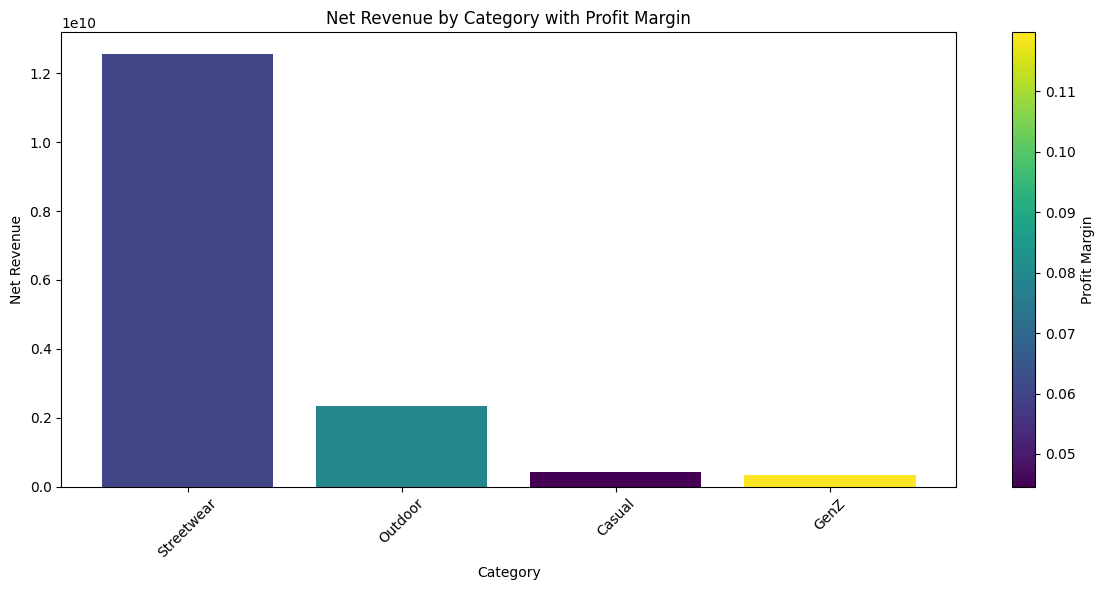

In [32]:

# ==============================
# 1. BAR CHART: DOANH THU THEO DANH MỤC + BIÊN LỢI NHUẬN
# ==============================
# Trả lời câu hỏi:
# - Nhóm sản phẩm nào đang gánh doanh thu nhưng biên lợi nhuận mỏng?

df_category = df_master.groupby('category').agg({
    'Net_Revenue': 'sum',
    'Target_Profit': 'sum'
}).reset_index()

df_category['Profit_Margin'] = np.where(
    df_category['Net_Revenue'] != 0,
    df_category['Target_Profit'] / df_category['Net_Revenue'],
    np.nan
)

df_category = df_category.sort_values('Net_Revenue', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

norm = plt.Normalize(df_category['Profit_Margin'].min(), df_category['Profit_Margin'].max())
colors = plt.cm.viridis(norm(df_category['Profit_Margin']))

ax.bar(df_category['category'], df_category['Net_Revenue'], color=colors)
ax.set_title('Net Revenue by Category with Profit Margin')
ax.set_xlabel('Category')
ax.set_ylabel('Net Revenue')
ax.tick_params(axis='x', rotation=45)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Profit Margin')

plt.tight_layout()
plt.show()


#### ***3.1.2. PARETO CHART: TOP SẢN PHẨM THEO DOANH THU***

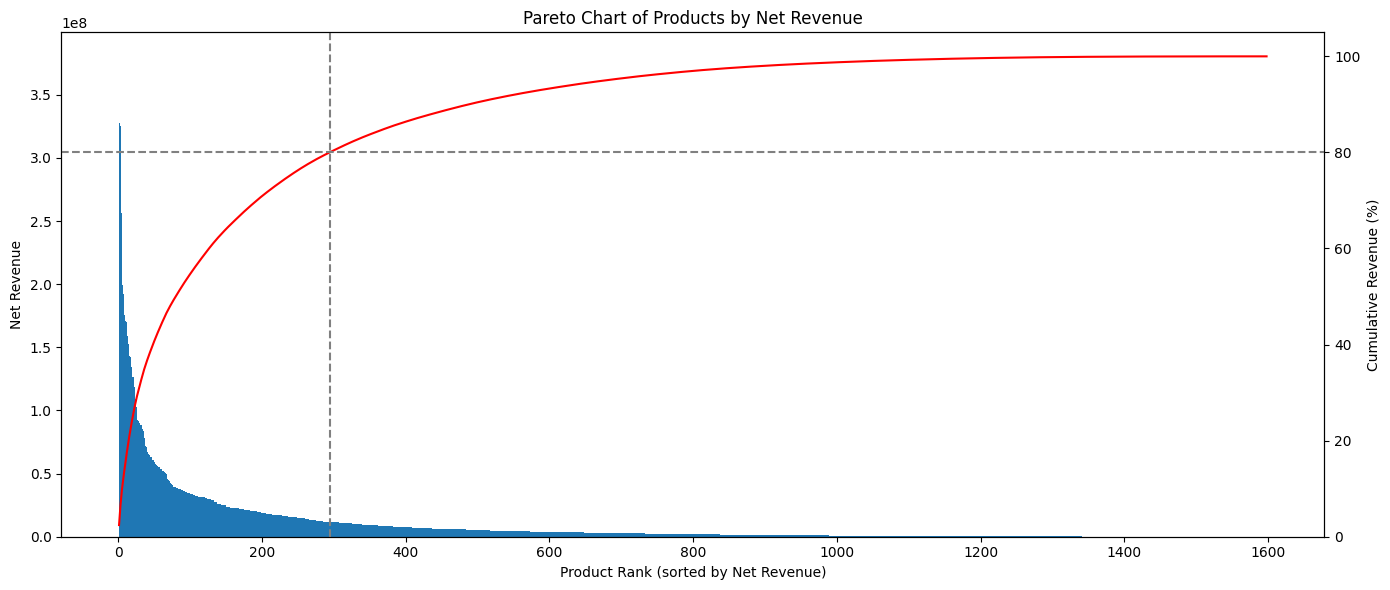

Top 294 products (18.40%) contribute 80% of total Net Revenue.


In [33]:
# ==============================
# 2. PARETO CHART: TOP SẢN PHẨM THEO DOANH THU
# ==============================
# Trả lời câu hỏi:
# - Đâu là 20% sản phẩm cốt lõi mang lại 80% doanh thu?

df_product_pareto = df_master.groupby(['product_id', 'product_name']).agg({
    'Net_Revenue': 'sum'
}).reset_index()

df_product_pareto = df_product_pareto.sort_values('Net_Revenue', ascending=False).reset_index(drop=True)
df_product_pareto['Cumulative_Revenue'] = df_product_pareto['Net_Revenue'].cumsum()
df_product_pareto['Cumulative_Pct'] = df_product_pareto['Cumulative_Revenue'] / df_product_pareto['Net_Revenue'].sum() * 100
df_product_pareto['Rank'] = np.arange(1, len(df_product_pareto) + 1)

pareto_80_idx = df_product_pareto[df_product_pareto['Cumulative_Pct'] >= 80].index[0]
pareto_80_count = pareto_80_idx + 1
pareto_80_share = pareto_80_count / len(df_product_pareto) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(df_product_pareto['Rank'], df_product_pareto['Net_Revenue'], width=1.0)
ax1.set_xlabel('Product Rank (sorted by Net Revenue)')
ax1.set_ylabel('Net Revenue')
ax1.set_title('Pareto Chart of Products by Net Revenue')

ax2 = ax1.twinx()
ax2.plot(df_product_pareto['Rank'], df_product_pareto['Cumulative_Pct'], color='red')
ax2.axhline(80, color='gray', linestyle='--')
ax2.axvline(pareto_80_count, color='gray', linestyle='--')
ax2.set_ylabel('Cumulative Revenue (%)')
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"Top {pareto_80_count} products ({pareto_80_share:.2f}%) contribute 80% of total Net Revenue.")

#### ***3.1.3. SCATTER PLOT: GIÁ VỐN VS GIÁ BÁN***

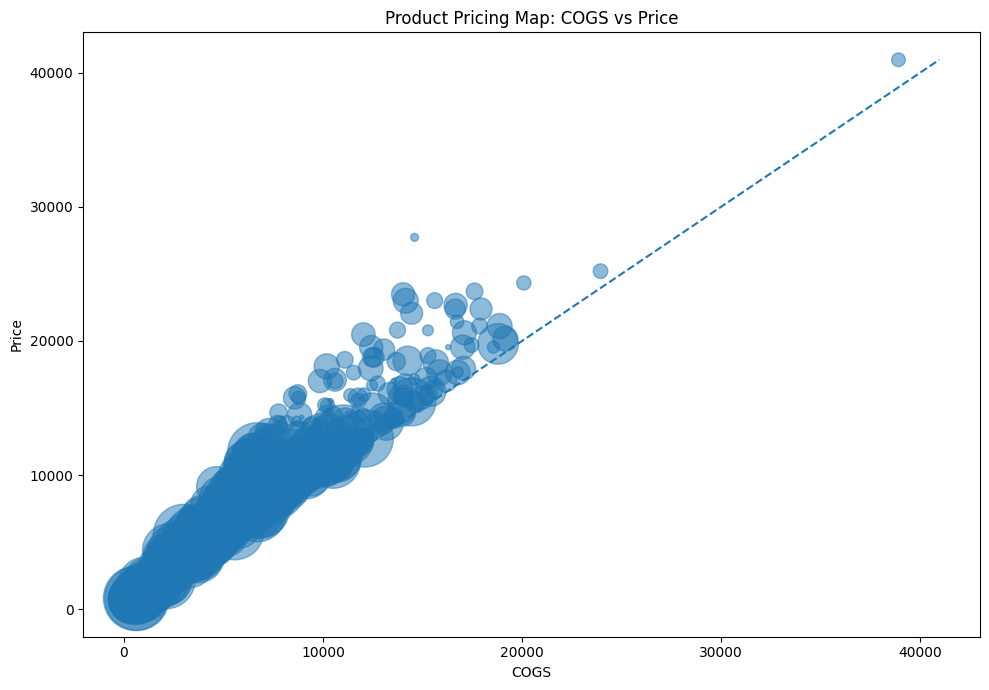

In [34]:
# ==============================
# 3. SCATTER PLOT: GIÁ VỐN VS GIÁ BÁN
# ==============================
# Trả lời câu hỏi:
# - Chiến lược giá có an toàn không?
# - Có sản phẩm nào rủi ro lỗ không?

df_product_price = df_master.groupby(['product_id', 'product_name']).agg({
    'cogs': 'first',
    'price': 'first',
    'quantity': 'sum',
    'Net_Revenue': 'sum',
    'Target_Profit': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))

size_scale = np.sqrt(df_product_price['quantity']) * 10
ax.scatter(
    df_product_price['cogs'],
    df_product_price['price'],
    s=size_scale,
    alpha=0.5
)

max_val = max(df_product_price['cogs'].max(), df_product_price['price'].max())
ax.plot([0, max_val], [0, max_val], linestyle='--')

ax.set_title('Product Pricing Map: COGS vs Price')
ax.set_xlabel('COGS')
ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

#### ***3.1.4. MULTI-LINE CHART: DOANH THU THEO QUÝ VÀ PHÂN KHÚC KHÁCH HÀNG***

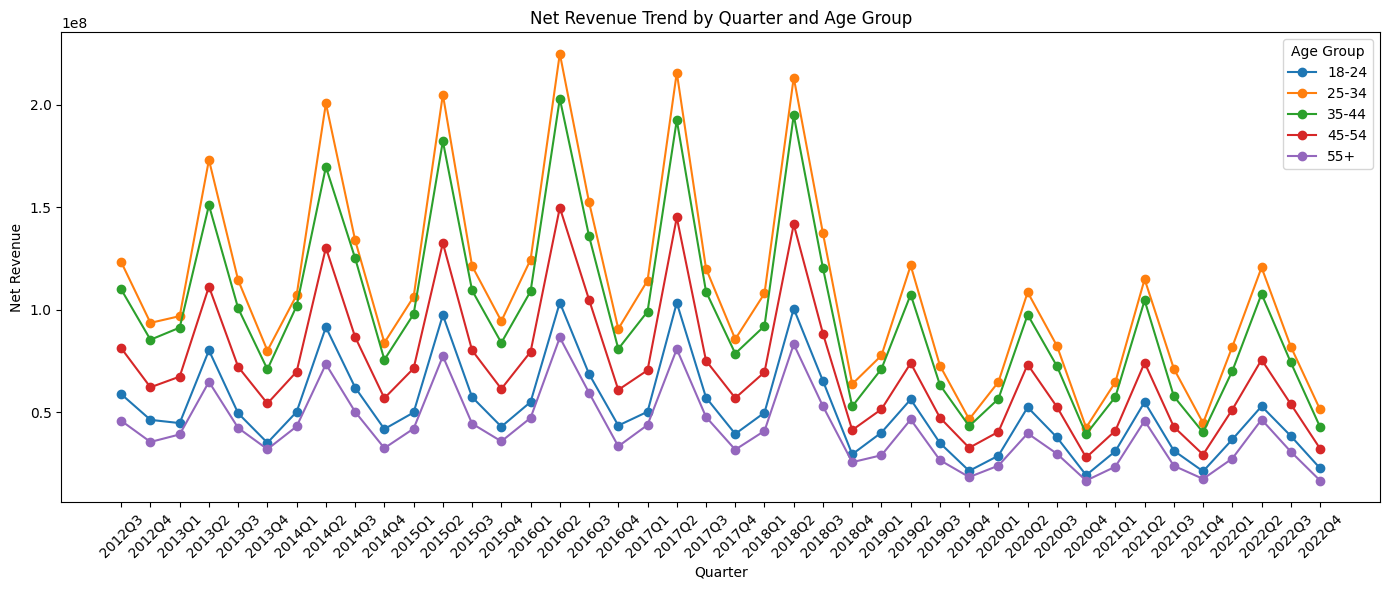

In [35]:
# ==============================
# 4. MULTI-LINE CHART: DOANH THU THEO QUÝ VÀ PHÂN KHÚC KHÁCH HÀNG
# ==============================
# Trả lời câu hỏi:
# - Phân khúc khách hàng nào đang tăng trưởng / suy thoái qua từng quý?
# Lưu ý:
# - Dùng age_group làm proxy cho phân khúc khách hàng vì schema hiện có không có customer_segment riêng

df_segment = df_master.copy()
df_segment['Quarter'] = df_segment['order_date'].dt.to_period('Q').astype(str)

df_segment_q = df_segment.groupby(['Quarter', 'age_group']).agg({
    'Net_Revenue': 'sum'
}).reset_index()

df_segment_pivot = df_segment_q.pivot(index='Quarter', columns='age_group', values='Net_Revenue').fillna(0)
df_segment_pivot.index = pd.PeriodIndex(df_segment_pivot.index, freq='Q')
df_segment_pivot = df_segment_pivot.sort_index()
df_segment_pivot.index = df_segment_pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

for col in df_segment_pivot.columns:
    ax.plot(df_segment_pivot.index, df_segment_pivot[col], marker='o', label=col)

ax.set_title('Net Revenue Trend by Quarter and Age Group')
ax.set_xlabel('Quarter')
ax.set_ylabel('Net Revenue')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group')

plt.tight_layout()
plt.show()

### **3.2 Góc nhìn 2: Hiệu quả khuyến mãi và mức độ “ăn mòn” doanh thu**
**Lý do chọn góc nhìn này:**

Khuyến mãi (Promo) là con dao hai lưỡi. Góc nhìn này giúp ban lãnh đạo trả lời câu hỏi nhức nhối: "Chúng ta đang dùng khuyến mãi để kích cầu người mua nhiều hơn, hay chỉ đang 'đốt tiền' trợ giá cho những khách hàng vốn dĩ vẫn sẽ mua hàng?".

**Câu hỏi cần trả lời -> Những biểu đồ phù hợp:**

* Khuyến mãi có thực sự làm tăng giá trị giỏ hàng không? -> **Boxplot** (Trục X: Có Promo vs Không Promo, Trục Y: Giá trị đơn hàng - AOV).

- Dòng tiền thực tế đã bị "ăn mòn" qua các rò rỉ nào trước khi thành lợi nhuận? -> **Waterfall chart** (Gross Revenue -> (-) Discount -> (-) Refund -> (+) Shipping -> Net Revenue).

- Loại mã khuyến mãi nào (%, BOGO, Freeship) hoạt động tốt nhất trên từng kênh bán? -> **Heatmap** (Dòng: Loại Promo, Cột: Kênh bán, Màu sắc: CVR hoặc Lợi nhuận ròng).

**Insight kỳ vọng => Kết luận (Hành động)**

In [36]:
# ------ 3.2 GÓC NHÌN 2: HIỆU QUẢ KHUYẾN MÃI VÀ MỨC ĐỘ ĂN MÒN DOANH THU ------

# Mục đích:
# - Đánh giá khuyến mãi có làm tăng giá trị giỏ hàng hay không
# - Phân rã dòng tiền để xem doanh thu bị "ăn mòn" ở đâu
# - So sánh hiệu quả các loại khuyến mãi trên từng kênh bán


# ==============================
# 0. CHUẨN BỊ BIẾN PHỤ
# ==============================
# Tạo cờ có khuyến mãi và loại khuyến mãi thực tế để phân tích

df_master['has_promo'] = np.where(
    (df_master['promo_id'] != 'NONE') | (df_master['promo_id_2'] != 'NONE'),
    'Có Promo',
    'Không Promo'
)

# Tạo mã khuyến mãi hiệu lực (ưu tiên promo_id, nếu rỗng thì lấy promo_id_2)
df_master['effective_promo_id'] = np.where(
    df_master['promo_id'] != 'NONE',
    df_master['promo_id'],
    np.where(df_master['promo_id_2'] != 'NONE', df_master['promo_id_2'], np.nan)
)

# Ghép loại khuyến mãi từ bảng promotions
df_promo_lookup = df_promotions[['promo_id', 'promo_type']].copy()
df_promo_lookup['promo_id'] = df_promo_lookup['promo_id'].astype(str)

df_master = df_master.merge(
    df_promo_lookup,
    left_on='effective_promo_id',
    right_on='promo_id',
    how='left'
)

df_master = df_master.rename(columns={'promo_type': 'Promo_Type'})
df_master['Promo_Type'] = df_master['Promo_Type'].fillna('No Promo')

#### ***3.2.1. BOXPLOT: KHÔNG PROMO VS CÓ PROMO***

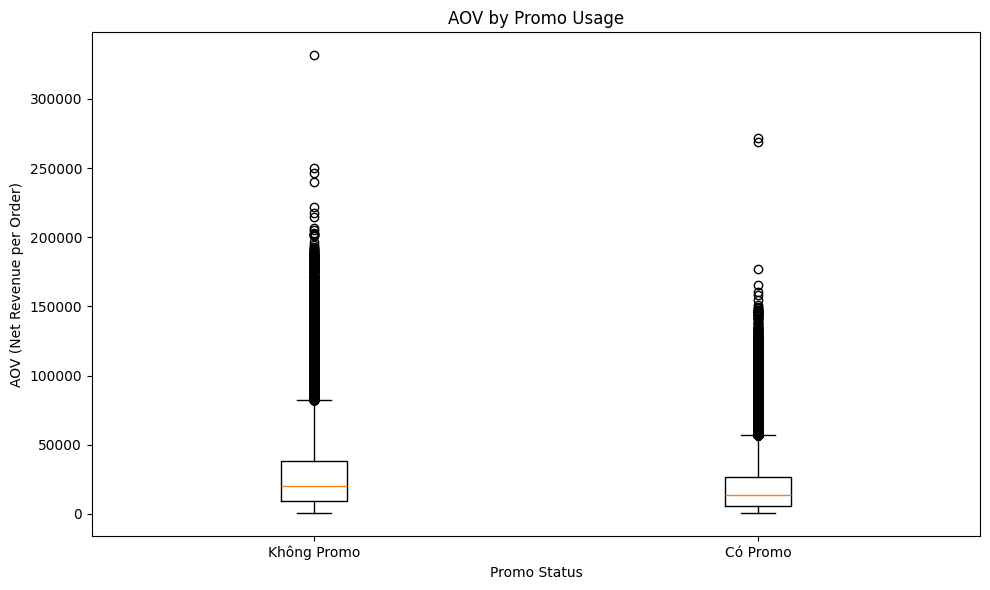

In [37]:
# ==============================
# 1. BOXPLOT: KHÔNG PROMO VS CÓ PROMO
# ==============================
# Trả lời câu hỏi:
# - Khuyến mãi có thực sự làm tăng giá trị đơn hàng (AOV) không?

df_aov = df_master.groupby(['order_id', 'has_promo']).agg({
    'Net_Revenue': 'sum'
}).reset_index()

aov_no_promo = df_aov.loc[df_aov['has_promo'] == 'Không Promo', 'Net_Revenue']
aov_with_promo = df_aov.loc[df_aov['has_promo'] == 'Có Promo', 'Net_Revenue']

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [aov_no_promo, aov_with_promo],
    tick_labels=['Không Promo', 'Có Promo']   # <- FIX ở đây
)

ax.set_title('AOV by Promo Usage')
ax.set_xlabel('Promo Status')
ax.set_ylabel('AOV (Net Revenue per Order)')

plt.tight_layout()
plt.show()


#### ***3.2.2. WATERFALL CHART: DÒNG TIỀN BỊ ĂN MÒN***

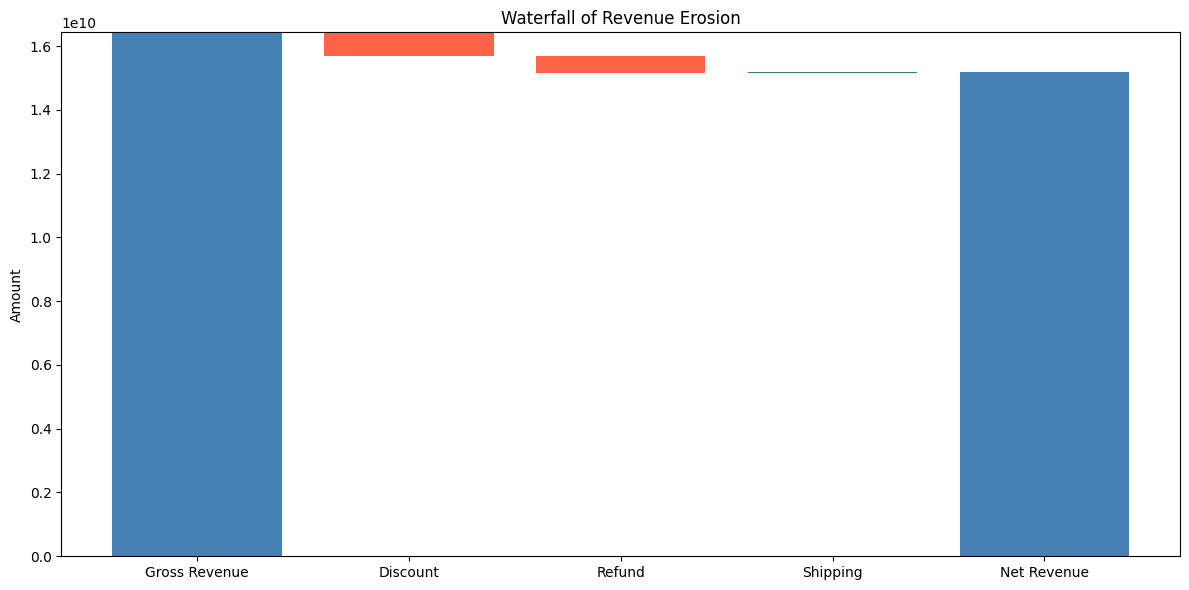

In [38]:

# ==============================
# 2. WATERFALL CHART: DÒNG TIỀN BỊ ĂN MÒN
# ==============================
# Trả lời câu hỏi:
# - Doanh thu bị giảm ở khâu nào trước khi còn lại lợi nhuận ròng?

gross_revenue = df_master['Gross_Revenue'].sum()
total_discount = df_master['discount_amount'].sum()
total_refund = df_master['refund_amount'].fillna(0).sum()
total_shipping = df_master['shipping_fee'].fillna(0).sum()
net_revenue = gross_revenue - total_discount - total_refund + total_shipping

waterfall_labels = ['Gross Revenue', 'Discount', 'Refund', 'Shipping', 'Net Revenue']
waterfall_values = [gross_revenue, -total_discount, -total_refund, total_shipping, net_revenue]

# Tính vị trí đáy cho từng cột
waterfall_bottoms = [0]
running_total = gross_revenue
waterfall_bottoms.append(running_total)
running_total -= total_discount
waterfall_bottoms.append(running_total)
running_total -= total_refund
waterfall_bottoms.append(running_total)
waterfall_bottoms.append(0)

fig, ax = plt.subplots(figsize=(12, 6))

# Cột đầu
ax.bar(waterfall_labels[0], waterfall_values[0], color='steelblue')

# Các cột điều chỉnh
ax.bar(waterfall_labels[1], waterfall_values[1], bottom=waterfall_bottoms[1], color='tomato')
ax.bar(waterfall_labels[2], waterfall_values[2], bottom=waterfall_bottoms[2], color='tomato')
ax.bar(waterfall_labels[3], waterfall_values[3], bottom=waterfall_bottoms[3], color='seagreen')

# Cột cuối
ax.bar(waterfall_labels[4], waterfall_values[4], color='steelblue')

ax.set_title('Waterfall of Revenue Erosion')
ax.set_ylabel('Amount')
plt.tight_layout()
plt.show()


#### ***3.2.3. HEATMAP: LOẠI PROMO THEO KÊNH BÁN***

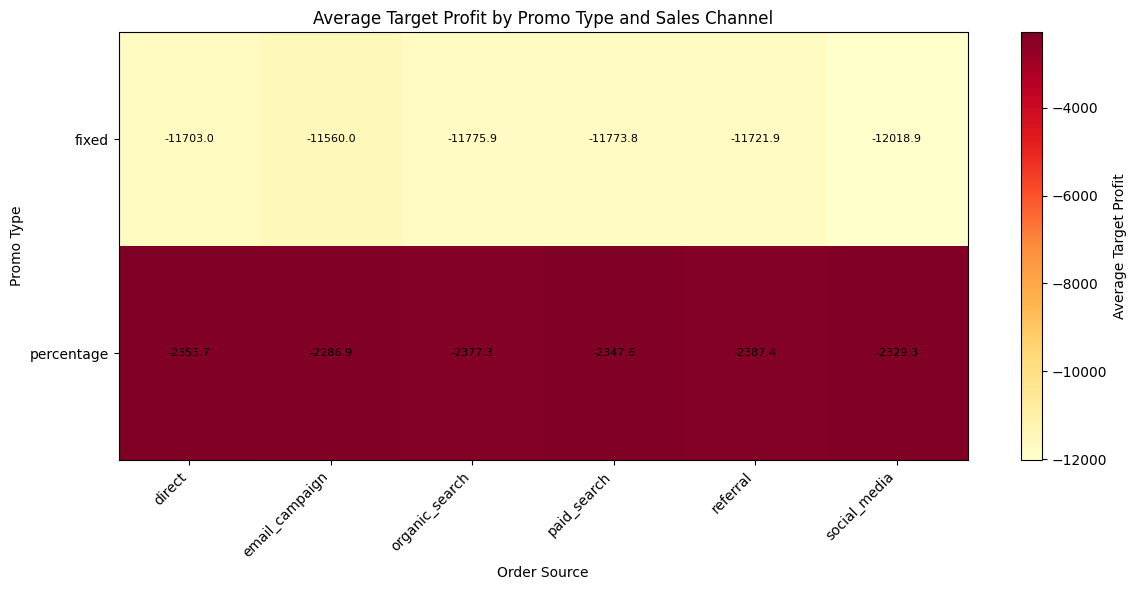

In [39]:
# ==============================
# 3. HEATMAP: LOẠI PROMO THEO KÊNH BÁN
# ==============================
# Trả lời câu hỏi:
# - Loại khuyến mãi nào hoạt động tốt nhất trên từng kênh bán?

# Chỉ lấy các dòng có khuyến mãi thật
df_promo_heat = df_master[df_master['Promo_Type'] != 'No Promo'].copy()

# Tổng lợi nhuận ròng theo loại promo và kênh bán
promo_heatmap = df_promo_heat.pivot_table(
    index='Promo_Type',
    columns='order_source',
    values='Target_Profit',
    aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(promo_heatmap.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(np.arange(len(promo_heatmap.columns)))
ax.set_xticklabels(promo_heatmap.columns, rotation=45, ha='right')

ax.set_yticks(np.arange(len(promo_heatmap.index)))
ax.set_yticklabels(promo_heatmap.index)

ax.set_title('Average Target Profit by Promo Type and Sales Channel')
ax.set_xlabel('Order Source')
ax.set_ylabel('Promo Type')

# Ghi số lên từng ô để dễ đọc
for i in range(promo_heatmap.shape[0]):
    for j in range(promo_heatmap.shape[1]):
        ax.text(j, i, f"{promo_heatmap.values[i, j]:.1f}", ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='Average Target Profit')
plt.tight_layout()
plt.show()

### **3.3 Góc nhìn 3: Hành vi khách hàng theo phân khúc, địa lý, kênh thu hút**
**Lý do chọn góc nhìn này:**

Chi phí để có một khách hàng mới (CAC) ngày càng đắt đỏ. Góc nhìn này giúp tối ưu hóa phễu bán hàng, biết được khách hàng giá trị cao ở đâu, và quan trọng nhất: họ có quay lại mua hàng (Retention) hay không.

**Câu hỏi cần trả lời -> Những biểu đồ phù hợp:**

- Khu vực địa lý nào đang tạo ra giá trị cao nhất trên mỗi khách hàng? -> Choropleth Map / Horizontal Bar (Vị trí: Region/Zip code, Màu/Độ dài: ARPU hoặc Tổng số đơn).

- Khách hàng đang "rơi rụng" nhiều nhất ở bước nào trong quy trình mua sắm? -> Funnel chart (Page Views -> Sessions -> Add to Cart -> Đặt hàng -> Giao thành công).

- Mỗi kênh marketing đang thu hút tệp khách hàng nào (tuổi/giới tính)? -> 100% Stacked Bar chart (Trục X: Tuổi/Giới tính, Trục Y: % Đóng góp, Chia lớp: Nguồn thu hút).

- Khách hàng chúng ta thu hút về có trung thành không? -> Cohort Matrix (Dòng: Tháng mua lần đầu, Cột: Tháng quay lại, Màu sắc: % Retention).

**Insight kỳ vọng => Kết luận (Hành động)**

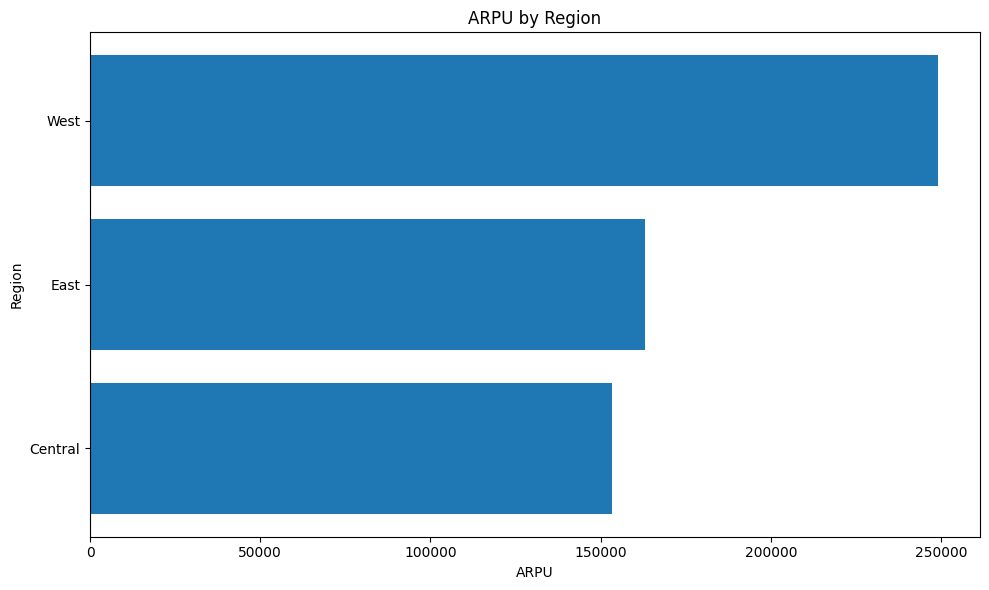

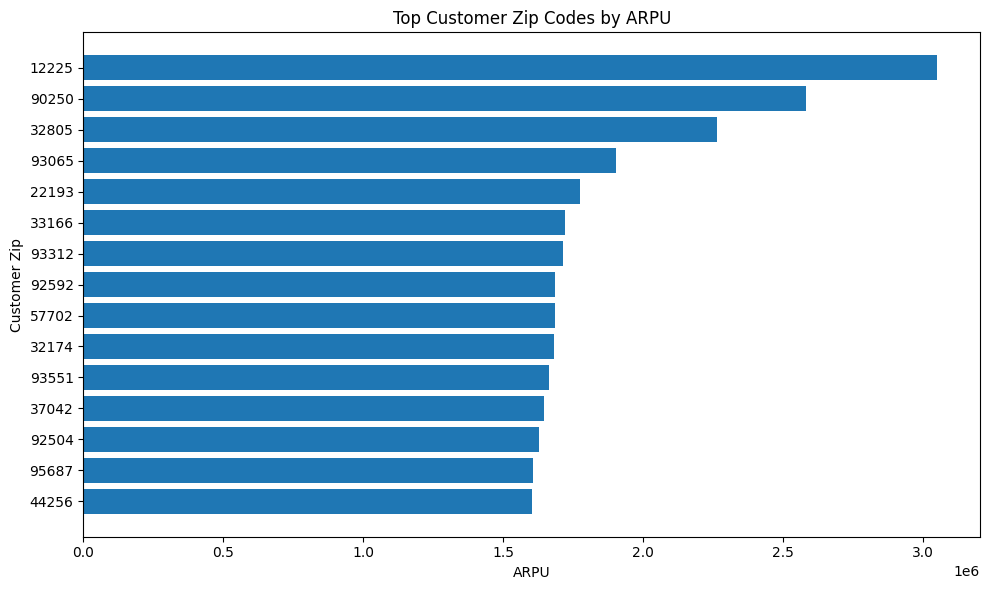

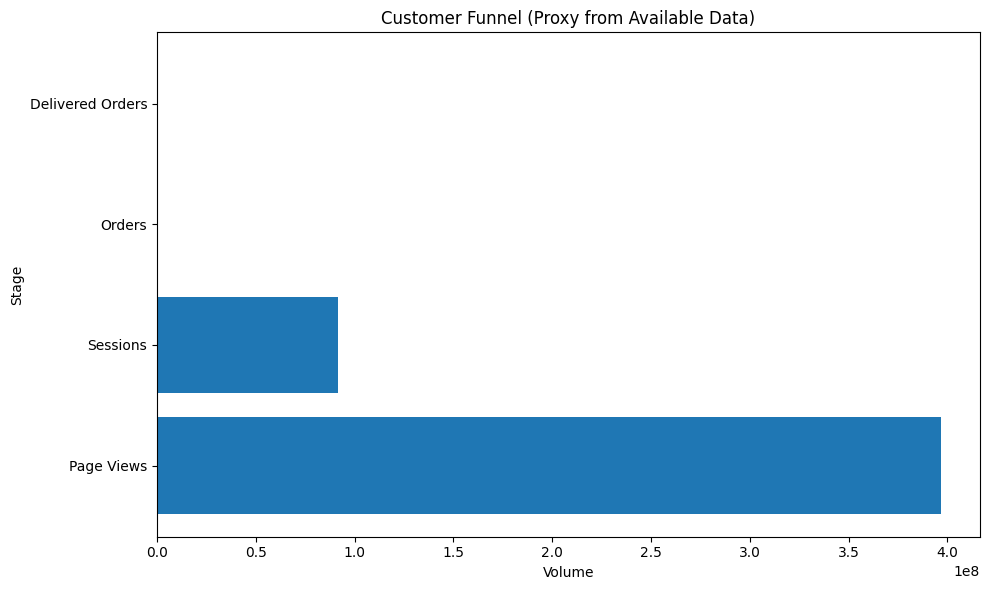

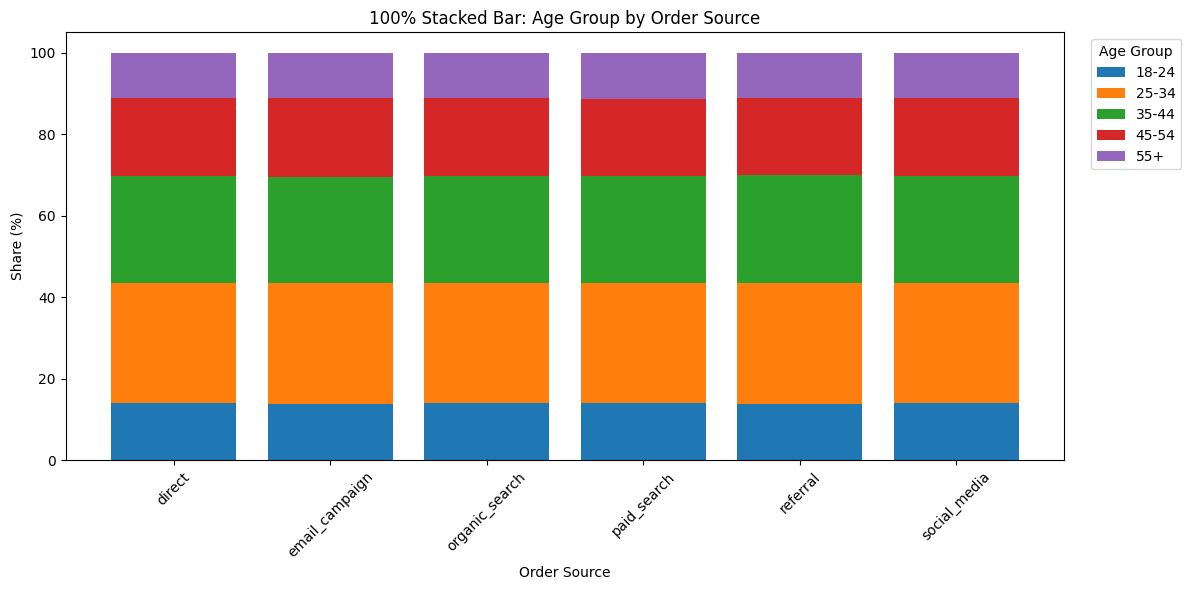

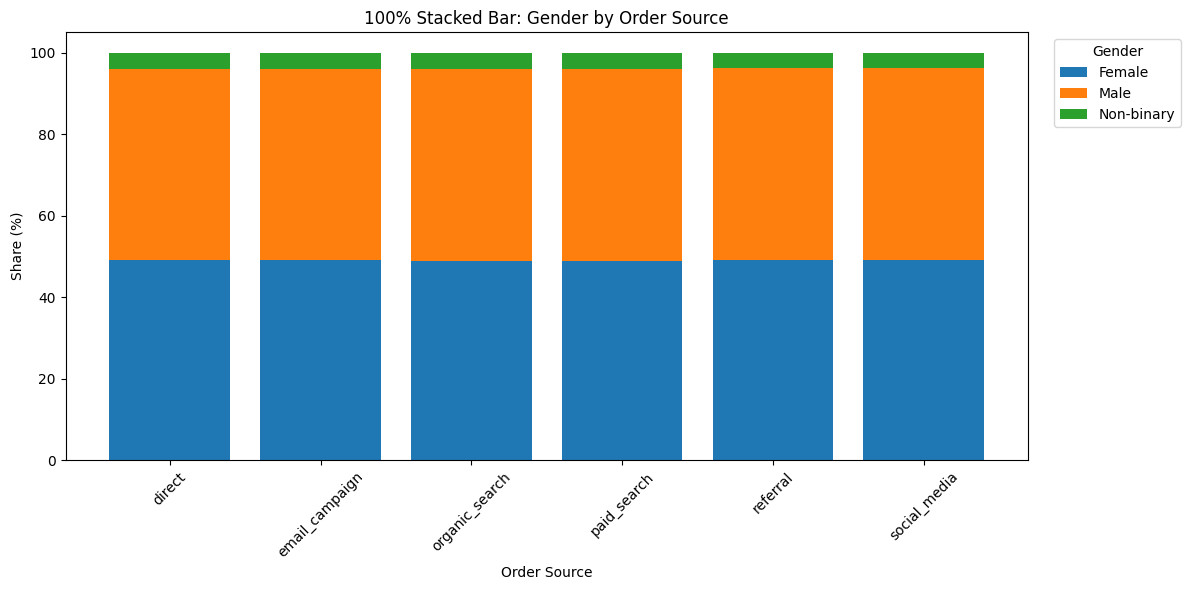

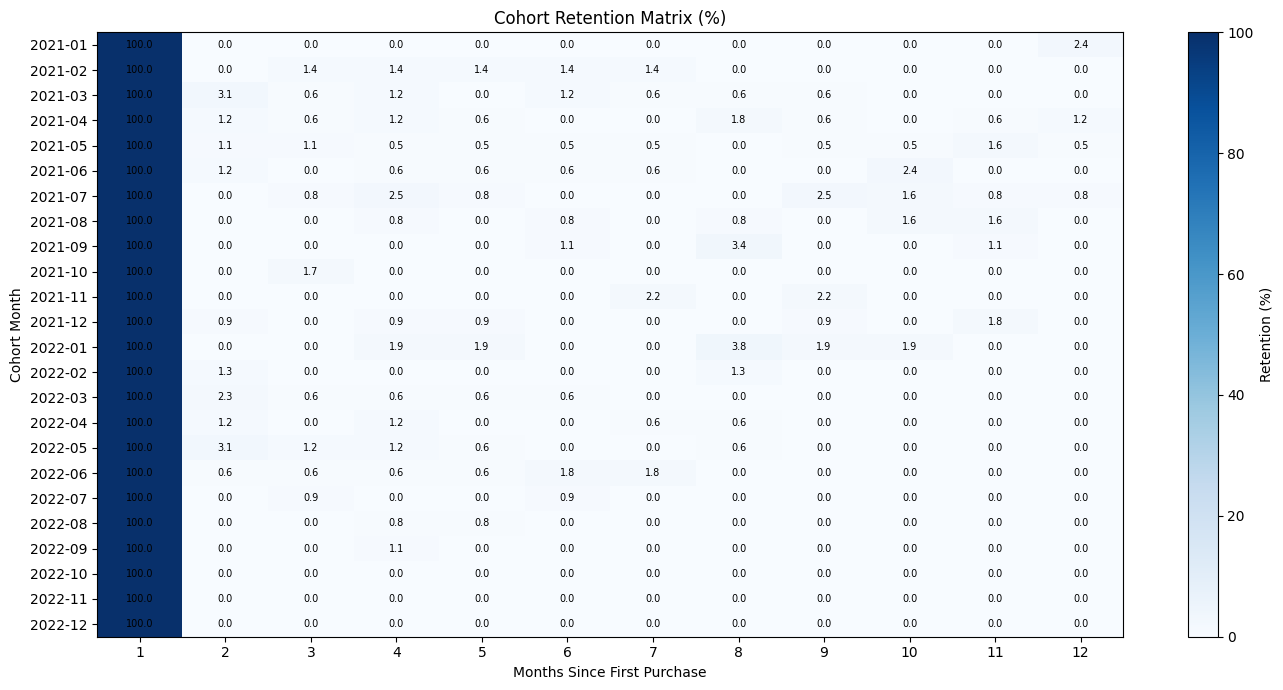

In [40]:
# ------ 3.3 GÓC NHÌN 3: HÀNH VI KHÁCH HÀNG THEO PHÂN KHÚC, ĐỊA LÝ, KÊNH THU HÚT ------

# Mục đích:
# - Xác định khu vực địa lý nào tạo ra giá trị cao nhất trên mỗi khách hàng
# - Phân tích phễu hành vi khách hàng bằng các chỉ số có sẵn trong dữ liệu
# - Xem mỗi kênh marketing đang thu hút tệp khách hàng nào theo độ tuổi và giới tính
# - Đánh giá mức độ quay lại mua hàng của khách theo cohort


# ==============================
# 0. CHUẨN BỊ DỮ LIỆU
# ==============================
# Dùng dữ liệu ở mức order để tránh đếm trùng theo order_items

df_order_level = df_master[
    ['order_id', 'customer_id', 'order_date', 'order_date_only', 'order_status',
     'order_source', 'age_group', 'gender', 'region', 'customer_zip',
     'Net_Revenue', 'sessions', 'page_views']
].drop_duplicates(subset=['order_id']).copy()

df_order_level['order_date'] = pd.to_datetime(df_order_level['order_date'], errors='coerce')
df_order_level['order_date_only'] = pd.to_datetime(df_order_level['order_date_only'], errors='coerce')


# ==============================
# 1. HORIZONTAL BAR: ARPU THEO VÙNG ĐỊA LÝ
# ==============================
# Trả lời câu hỏi:
# - Khu vực địa lý nào đang tạo ra giá trị cao nhất trên mỗi khách hàng?

df_region = df_master.groupby('region').agg({
    'Net_Revenue': 'sum',
    'customer_id': 'nunique'
}).reset_index().rename(columns={'customer_id': 'Unique_Customers'})

df_region['ARPU'] = np.where(
    df_region['Unique_Customers'] != 0,
    df_region['Net_Revenue'] / df_region['Unique_Customers'],
    np.nan
)

df_region = df_region.sort_values('ARPU', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_region['region'], df_region['ARPU'])
ax.set_title('ARPU by Region')
ax.set_xlabel('ARPU')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()


# ==============================
# 2. HORIZONTAL BAR: TOP ZIP THEO ARPU
# ==============================
# Trả lời câu hỏi:
# - Zip code nào tạo ra giá trị cao nhất trên mỗi khách hàng?
# Lưu ý:
# - Dùng customer_zip vì đang đo giá trị theo khách hàng, không phải địa chỉ giao hàng

df_zip = df_master.groupby('customer_zip').agg({
    'Net_Revenue': 'sum',
    'customer_id': 'nunique'
}).reset_index().rename(columns={'customer_id': 'Unique_Customers'})

df_zip['ARPU'] = np.where(
    df_zip['Unique_Customers'] != 0,
    df_zip['Net_Revenue'] / df_zip['Unique_Customers'],
    np.nan
)

df_zip = df_zip.sort_values('ARPU', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_zip['customer_zip'].astype(str), df_zip['ARPU'])
ax.set_title('Top Customer Zip Codes by ARPU')
ax.set_xlabel('ARPU')
ax.set_ylabel('Customer Zip')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# ==============================
# 3. FUNNEL CHART: PHỄU HÀNH VI KHÁCH HÀNG
# ==============================
# Trả lời câu hỏi:
# - Khách hàng đang rơi rụng ở bước nào?
# Lưu ý:
# - Schema không có Add to Cart
# - Dùng proxy theo dữ liệu sẵn có: Page Views -> Sessions -> Orders -> Delivered Orders

df_web_daily = df_master[['order_date_only', 'sessions', 'page_views']].drop_duplicates(subset=['order_date_only']).copy()
df_web_daily['sessions'] = df_web_daily['sessions'].fillna(0)
df_web_daily['page_views'] = df_web_daily['page_views'].fillna(0)

page_views = df_web_daily['page_views'].sum()
sessions = df_web_daily['sessions'].sum()
orders = df_master['order_id'].nunique()
delivered_orders = df_order_level.loc[
    df_order_level['order_status'].astype(str).str.lower() == 'delivered',
    'order_id'
].nunique()

funnel_labels = ['Page Views', 'Sessions', 'Orders', 'Delivered Orders']
funnel_values = [page_views, sessions, orders, delivered_orders]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(funnel_labels, funnel_values)
ax.set_title('Customer Funnel (Proxy from Available Data)')
ax.set_xlabel('Volume')
ax.set_ylabel('Stage')
plt.tight_layout()
plt.show()


# ==============================
# 4. 100% STACKED BAR: TUỔI THEO KÊNH THU HÚT
# ==============================
# Trả lời câu hỏi:
# - Mỗi kênh marketing đang thu hút tệp khách hàng nào theo độ tuổi?

df_age_source = df_order_level.groupby(['order_source', 'age_group']).agg({
    'customer_id': 'nunique'
}).reset_index().rename(columns={'customer_id': 'Unique_Customers'})

df_age_pivot = df_age_source.pivot(index='order_source', columns='age_group', values='Unique_Customers').fillna(0)
df_age_pct = df_age_pivot.div(df_age_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(df_age_pct.index))

for col in df_age_pct.columns:
    ax.bar(df_age_pct.index, df_age_pct[col], bottom=bottom, label=col)
    bottom += df_age_pct[col].values

ax.set_title('100% Stacked Bar: Age Group by Order Source')
ax.set_xlabel('Order Source')
ax.set_ylabel('Share (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ==============================
# 5. 100% STACKED BAR: GIỚI TÍNH THEO KÊNH THU HÚT
# ==============================
# Trả lời câu hỏi:
# - Mỗi kênh marketing đang thu hút tệp khách hàng nào theo giới tính?

df_gender_source = df_order_level.groupby(['order_source', 'gender']).agg({
    'customer_id': 'nunique'
}).reset_index().rename(columns={'customer_id': 'Unique_Customers'})

df_gender_pivot = df_gender_source.pivot(index='order_source', columns='gender', values='Unique_Customers').fillna(0)
df_gender_pct = df_gender_pivot.div(df_gender_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(df_gender_pct.index))

for col in df_gender_pct.columns:
    ax.bar(df_gender_pct.index, df_gender_pct[col], bottom=bottom, label=col)
    bottom += df_gender_pct[col].values

ax.set_title('100% Stacked Bar: Gender by Order Source')
ax.set_xlabel('Order Source')
ax.set_ylabel('Share (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ==============================
# 6. COHORT MATRIX: RETENTION THEO THÁNG MUA ĐẦU
# ==============================
# Trả lời câu hỏi:
# - Khách hàng có quay lại mua hàng hay không?
# - Cohort = tháng mua đầu tiên
# - Retention = % khách quay lại ở các tháng sau
# - Chỉ hiển thị 24 cohort gần nhất để biểu đồ dễ đọc

df_cohort = df_master[['customer_id', 'order_id', 'order_date']].drop_duplicates(subset=['order_id']).copy()
df_cohort['order_date'] = pd.to_datetime(df_cohort['order_date'], errors='coerce')
df_cohort['order_month'] = df_cohort['order_date'].dt.to_period('M')

df_cohort['cohort_month'] = df_cohort.groupby('customer_id')['order_month'].transform('min')

df_cohort['cohort_index'] = (
    (df_cohort['order_month'].dt.year - df_cohort['cohort_month'].dt.year) * 12
    + (df_cohort['order_month'].dt.month - df_cohort['cohort_month'].dt.month)
    + 1
)

df_cohort = df_cohort[df_cohort['cohort_index'] <= 12]

cohort_counts = df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_matrix = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_id').fillna(0)

cohort_sizes = cohort_matrix[1]
retention_matrix = cohort_matrix.div(cohort_sizes, axis=0) * 100
retention_matrix = retention_matrix.tail(24)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(retention_matrix.values, aspect='auto', cmap='Blues')

ax.set_title('Cohort Retention Matrix (%)')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')

ax.set_xticks(np.arange(retention_matrix.shape[1]))
ax.set_xticklabels(retention_matrix.columns)

ax.set_yticks(np.arange(retention_matrix.shape[0]))
ax.set_yticklabels(retention_matrix.index.astype(str))

for i in range(retention_matrix.shape[0]):
    for j in range(retention_matrix.shape[1]):
        val = retention_matrix.values[i, j]
        ax.text(j, i, f"{val:.1f}", ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=ax, label='Retention (%)')
plt.tight_layout()
plt.show()

### **3.4 Góc nhìn 4: Hiệu quả vận hành (Tồn kho, Stockout, Trả hàng, Đánh giá)**
**Lý do chọn góc nhìn này:**

Vận hành là hậu phương của sales. Tiền marketing và sales đổ về sẽ trở nên vô nghĩa nếu hệ thống bị đứt gãy hàng hóa, đọng vốn do tồn kho ảo, hoặc thương hiệu bị hủy hoại do hàng lỗi bị hoàn trả quá nhiều.

**Câu hỏi cần trả lời -> Những biểu đồ phù hợp:**

- Sản phẩm nào đang đối mặt với rủi ro đứt hàng (bán nhanh) hoặc chôn vốn (bán chậm)? -> Scatter plot (Trục X: Tồn kho hiện tại, Trục Y: Tốc độ bán/Sell-through rate). Phân tích 4 góc tư.

- Việc hết hàng (Stockout) đang làm chúng ta mất bao nhiêu doanh thu tiềm năng? -> Dual-axis Line chart (Trục X: Thời gian, Y1: Số ngày hết hàng, Y2: Lượng truy cập trang/Nhu cầu).

- Tại sao khách hàng lại trả hàng? -> Horizontal Bar chart (Trục Y: Lý do trả hàng, Trục X: Giá trị tiền hoàn).

- Đâu là những "bom nổ chậm" (bán nhiều nhưng bị đánh giá tệ và hoàn trả cao)? -> Bubble chart (Trục X: Điểm đánh giá, Trục Y: Tỷ lệ trả hàng, Kích thước: Khối lượng bán).

**Insight kỳ vọng => Kết luận (Hành động)**

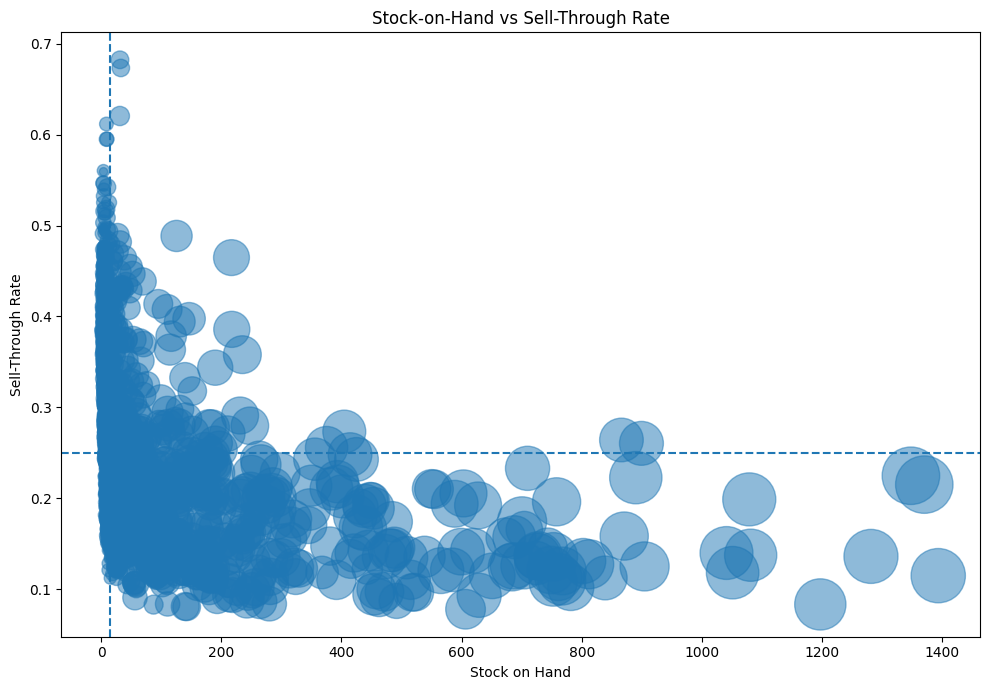

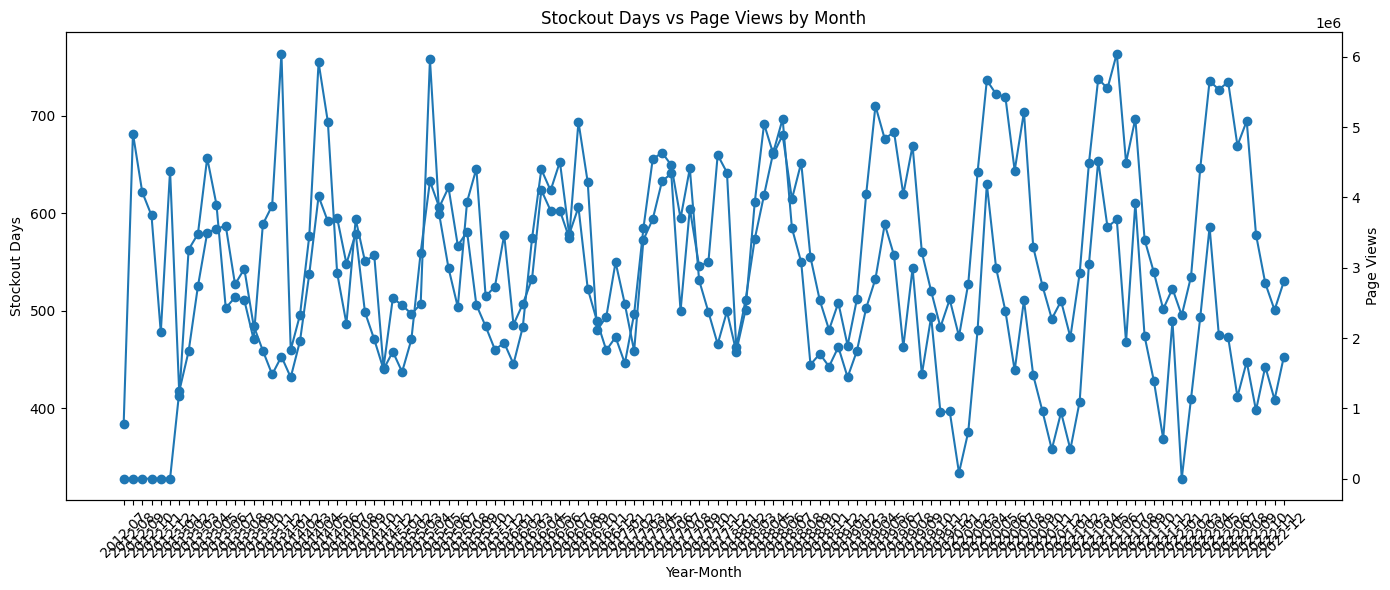

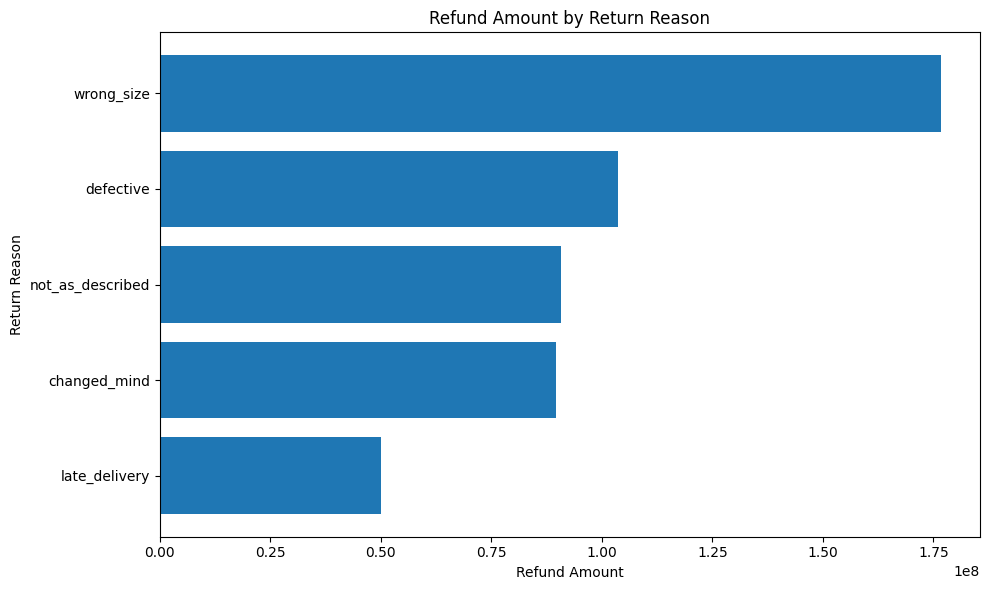

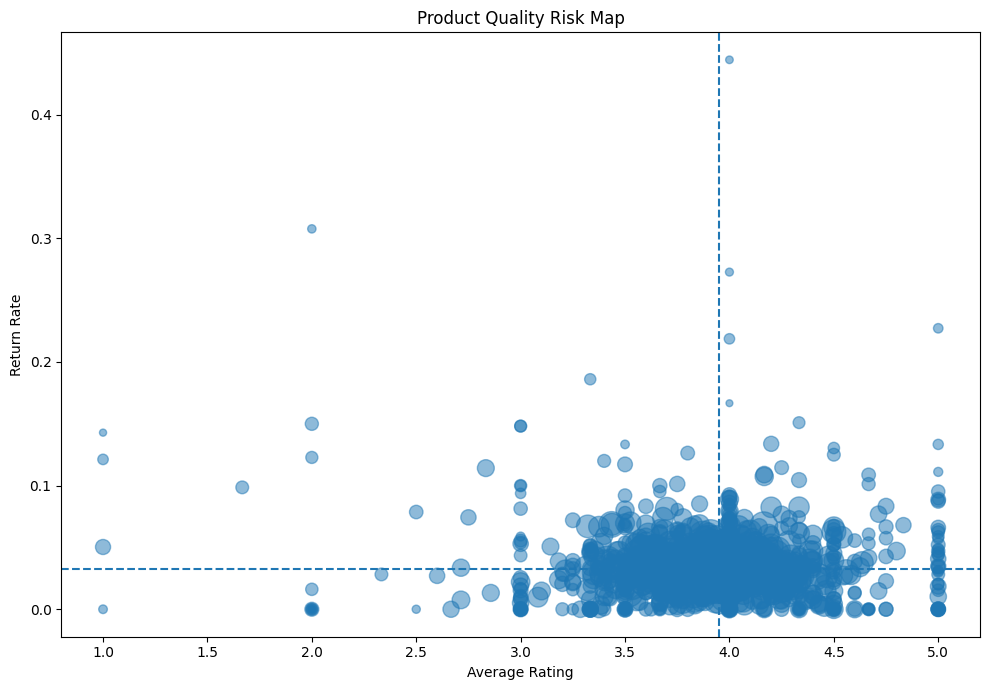

In [41]:
# ------ 3.4 GÓC NHÌN 4: HIỆU QUẢ VẬN HÀNH (TỒN KHO, STOCKOUT, TRẢ HÀNG, ĐÁNH GIÁ) ------

# Mục đích:
# - Tìm sản phẩm có nguy cơ đứt hàng hoặc chôn vốn
# - Xem stockout đang đi cùng mức nhu cầu truy cập như thế nào theo thời gian
# - Xác định lý do trả hàng chính
# - Phát hiện các sản phẩm "bán nhiều nhưng bị chê và trả nhiều"


# ==============================
# 0. CHUẨN BỊ DỮ LIỆU
# ==============================
# Lưu ý:
# - Inventory và web traffic có grain riêng, nên cần gom đúng mức để tránh đếm trùng
# - Return reason không có trong df_master, nên lấy từ df_returns

df_master['YearMonth'] = pd.to_datetime(df_master['order_date_only'], errors='coerce').dt.to_period('M').astype(str)


# ==============================
# 1. SCATTER PLOT: TỒN KHO VS SELL-THROUGH
# ==============================
# Trả lời câu hỏi:
# - Sản phẩm nào có rủi ro đứt hàng hoặc chôn vốn?
# - Phân tích 4 góc tư theo tồn kho hiện tại và tốc độ bán

df_stock_product = df_master[['product_id', 'product_name', 'stock_on_hand', 'sell_through_rate', 'quantity']].copy()

df_stock_product = df_stock_product.groupby(['product_id', 'product_name']).agg({
    'stock_on_hand': 'mean',
    'sell_through_rate': 'mean',
    'quantity': 'sum'
}).reset_index()

# Loại bỏ các dòng thiếu dữ liệu quan trọng
df_stock_product = df_stock_product.dropna(subset=['stock_on_hand', 'sell_through_rate'])

x_median = df_stock_product['stock_on_hand'].median()
y_median = df_stock_product['sell_through_rate'].median()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_stock_product['stock_on_hand'],
    df_stock_product['sell_through_rate'],
    s=np.sqrt(df_stock_product['quantity']) * 8,
    alpha=0.5
)

# Đường chia 4 góc tư
ax.axvline(x_median, linestyle='--')
ax.axhline(y_median, linestyle='--')

ax.set_title('Stock-on-Hand vs Sell-Through Rate')
ax.set_xlabel('Stock on Hand')
ax.set_ylabel('Sell-Through Rate')

plt.tight_layout()
plt.show()


# ==============================
# 2. DUAL-AXIS LINE: STOCKOUT VS NHU CẦU TRUY CẬP
# ==============================
# Trả lời câu hỏi:
# - Việc hết hàng đang xảy ra cùng với nhu cầu truy cập như thế nào theo thời gian?
# - Dùng stockout_days từ inventory và page_views/sessions từ web traffic

# Gom stockout theo tháng ở mức product-month để tránh nhân dòng
df_stock_month = df_master[['product_id', 'YearMonth', 'stockout_days']].drop_duplicates(subset=['product_id', 'YearMonth']).copy()
df_stock_month['stockout_days'] = pd.to_numeric(df_stock_month['stockout_days'], errors='coerce').fillna(0)

df_stock_month = df_stock_month.groupby('YearMonth').agg({
    'stockout_days': 'sum'
}).reset_index()

# Gom web traffic theo tháng ở mức ngày rồi tổng hợp lên tháng
df_traffic_daily = df_master[['order_date_only', 'sessions', 'page_views']].drop_duplicates(subset=['order_date_only']).copy()
df_traffic_daily['order_date_only'] = pd.to_datetime(df_traffic_daily['order_date_only'], errors='coerce')
df_traffic_daily['YearMonth'] = df_traffic_daily['order_date_only'].dt.to_period('M').astype(str)

df_traffic_month = df_traffic_daily.groupby('YearMonth').agg({
    'sessions': 'sum',
    'page_views': 'sum'
}).reset_index()

df_stock_traffic = df_stock_month.merge(df_traffic_month, on='YearMonth', how='left').fillna(0)
df_stock_traffic['YearMonth'] = pd.PeriodIndex(df_stock_traffic['YearMonth'], freq='M')
df_stock_traffic = df_stock_traffic.sort_values('YearMonth')

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_stock_traffic['YearMonth'].astype(str), df_stock_traffic['stockout_days'], marker='o')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Stockout Days')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_stock_traffic['YearMonth'].astype(str), df_stock_traffic['page_views'], marker='o')
ax2.set_ylabel('Page Views')

ax1.set_title('Stockout Days vs Page Views by Month')
plt.tight_layout()
plt.show()


# ==============================
# 3. HORIZONTAL BAR: LÝ DO TRẢ HÀNG
# ==============================
# Trả lời câu hỏi:
# - Tại sao khách hàng lại trả hàng?
# - Dùng refund_amount để phản ánh mức độ ảnh hưởng tài chính của từng lý do

df_return_reason = df_returns[['return_reason', 'refund_amount']].copy()
df_return_reason['refund_amount'] = pd.to_numeric(df_return_reason['refund_amount'], errors='coerce').fillna(0)

df_return_reason = df_return_reason.groupby('return_reason').agg({
    'refund_amount': 'sum'
}).reset_index()

df_return_reason = df_return_reason.sort_values('refund_amount', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_return_reason['return_reason'], df_return_reason['refund_amount'])
ax.set_title('Refund Amount by Return Reason')
ax.set_xlabel('Refund Amount')
ax.set_ylabel('Return Reason')
plt.tight_layout()
plt.show()


# ==============================
# 4. BUBBLE CHART: BOM NỔ CHẬM
# ==============================
# Trả lời câu hỏi:
# - Sản phẩm nào bán nhiều nhưng bị đánh giá tệ và hoàn trả cao?

df_bubble = df_master.groupby(['product_id', 'product_name']).agg({
    'quantity': 'sum',
    'return_quantity': 'sum',
    'avg_rating': 'mean'
}).reset_index()

# Tính tỷ lệ trả hàng
df_bubble['return_rate'] = np.where(
    df_bubble['quantity'] != 0,
    df_bubble['return_quantity'].fillna(0) / df_bubble['quantity'],
    np.nan
)

# Loại bỏ dòng thiếu rating để vẽ bubble chart rõ hơn
df_bubble = df_bubble.dropna(subset=['avg_rating', 'return_rate'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    df_bubble['avg_rating'],
    df_bubble['return_rate'],
    s=np.sqrt(df_bubble['quantity']) * 10,
    alpha=0.5
)

# Đường tham chiếu trung vị để nhìn nhanh 4 nhóm
ax.axvline(df_bubble['avg_rating'].median(), linestyle='--')
ax.axhline(df_bubble['return_rate'].median(), linestyle='--')

ax.set_title('Product Quality Risk Map')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Return Rate')

plt.tight_layout()
plt.show()

# **Phần 4: Xây dựng và Huấn luyện Mô hình Dự báo Doanh thu & Giá vốn**

---

## 📋 Tổng quan

| Hạng mục | Chi tiết |
|---|---|
| **Bài toán** | Time Series Forecasting — Dự báo `Revenue` và `COGS` theo ngày |
| **Tập train** | `sales.csv` — 04/07/2012 → 31/12/2022 (~3.800 ngày) |
| **Tập test** | 01/01/2023 → 01/07/2024 (548 ngày) |
| **Metric** | RMSE (Root Mean Squared Error) |
| **Mục tiêu** | RMSE ≤ 624,203.86 |
| **Approach** | ML-based Time Series với LightGBM + Optuna Tuning + Ensemble |

---

## 🗺️ Lộ trình kỹ thuật

```
4.1  Setup & Load Data
4.2  Time Series EDA  (trend, seasonality, ACF/PACF)
4.3  Feature Engineering  (lags, rolling stats, calendar, Fourier, exogenous)
4.4  Train / Validation Split  (walk-forward)
4.5  Baseline Models  (Naive, Seasonal Naive)
4.6  LightGBM  (Revenue & COGS)
4.7  XGBoost  (Revenue & COGS)
4.8  Hyperparameter Tuning  (Optuna)
4.9  Ensemble & Blending
4.10 Evaluation & Error Analysis
4.11 Generate Submission File
```

## **4.1 Setup & Load Data**

In [53]:
# ============================================================
# 4.1 SETUP — CÀI ĐẶT THƯ VIỆN & CẤU HÌNH
# ============================================================
# Mục đích:
# - Import toàn bộ thư viện cần thiết
# - Đặt seed ngẫu nhiên để đảm bảo kết quả tái lập
# - Cấu hình đường dẫn dữ liệu


# --- Core ---
import pandas as pd
import numpy as np
import warnings
import os
import json
from pathlib import Path

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

!pip install seaborn --quiet
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- Time Series Analysis ---
!pip install statsmodels --quiet
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Machine Learning ---
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# --- Gradient Boosting ---
import lightgbm as lgb
import xgboost as xgb

# --- Hyperparameter Tuning ---
!pip install optuna --quiet
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # tắt verbose log

# --- Global Settings ---
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 60)
SEED = 42
np.random.seed(SEED)

# --- Màu sắc nhất quán ---
COLOR_REV  = '#2196F3'   # Revenue → xanh dương
COLOR_COGS = '#FF5722'   # COGS    → cam đỏ
COLOR_PRED = '#4CAF50'   # Dự báo  → xanh lá

print('✅ Setup hoàn tất — LightGBM:', lgb.__version__, '| XGBoost:', xgb.__version__)

✅ Setup hoàn tất — LightGBM: 4.6.0 | XGBoost: 3.2.0


In [54]:
# ============================================================
# LOAD DỮ LIỆU
# ============================================================
# Mục đích:
# - Tải sales.csv (tập train) và web_traffic.csv (dữ liệu phụ)
# - Parse cột ngày đúng định dạng
# - Sắp xếp theo thời gian và đặt Date làm index

BASE_PATH = 'C:/Users/Lenovo/Downloads/datathon-2026-round-1/'   # ← Đổi nếu cần

# --- Tải sales train ---
df_sales = pd.read_csv(BASE_PATH + 'sales.csv', parse_dates=['Date'])
df_sales = df_sales.sort_values('Date').reset_index(drop=True)

# --- Tải web traffic (dữ liệu phụ cho exogenous features) ---
df_traffic = pd.read_csv(BASE_PATH + 'web_traffic.csv', parse_dates=['date'])
df_traffic = df_traffic.rename(columns={'date': 'Date'})
df_traffic = df_traffic.sort_values('Date').reset_index(drop=True)

# --- Tải promotions (để tạo feature promo_active) ---
df_promo = pd.read_csv(BASE_PATH + 'promotions.csv', parse_dates=['start_date', 'end_date'])

# --- Tải sample submission để biết cần dự báo ngày nào ---
df_submission_template = pd.read_csv(BASE_PATH + 'sample_submission.csv', parse_dates=['Date'])

print('📊 Sales train shape    :', df_sales.shape)
print('📅 Sales date range     :', df_sales['Date'].min().date(), '→', df_sales['Date'].max().date())
print('🌐 Web traffic shape    :', df_traffic.shape)
print('🎟️  Promotions shape     :', df_promo.shape)
print('📋 Submission template  :', df_submission_template.shape)
print()
print(df_sales.head(3))

📊 Sales train shape    : (3833, 3)
📅 Sales date range     : 2012-07-04 → 2022-12-31
🌐 Web traffic shape    : (3652, 7)
🎟️  Promotions shape     : (50, 10)
📋 Submission template  : (548, 3)

        Date      Revenue         COGS
0 2012-07-04 5,123,547.94 3,982,991.19
1 2012-07-05 2,751,773.45 2,150,580.23
2 2012-07-06 3,054,029.42 2,517,632.84


In [55]:
# ============================================================
# KIỂM TRA CHẤT LƯỢNG DỮ LIỆU
# ============================================================

print('=== MISSING VALUES ===')
print(df_sales.isnull().sum())

# Kiểm tra khoảng trống trong chuỗi thời gian (ngày bị thiếu)
all_dates = pd.date_range(df_sales['Date'].min(), df_sales['Date'].max(), freq='D')
missing_dates = all_dates.difference(df_sales['Date'])
print(f'\n=== MISSING DATES: {len(missing_dates)} ngày ===')
if len(missing_dates) > 0:
    print('Ngày bị thiếu:', missing_dates[:10].tolist())

# Điền ngày bị thiếu bằng forward-fill nếu có
if len(missing_dates) > 0:
    df_sales = df_sales.set_index('Date').reindex(all_dates).ffill().reset_index()
    df_sales.rename(columns={'index': 'Date'}, inplace=True)
    print('✅ Đã điền ngày bị thiếu bằng forward-fill')

print('\n=== STATISTICS ===')
print(df_sales[['Revenue', 'COGS']].describe())

=== MISSING VALUES ===
Date       0
Revenue    0
COGS       0
dtype: int64

=== MISSING DATES: 0 ngày ===

=== STATISTICS ===
            Revenue          COGS
count      3,833.00      3,833.00
mean   4,286,584.03  3,695,134.49
std    2,624,840.20  2,219,788.77
min      279,813.94    236,576.31
25%    2,471,088.82  2,150,580.23
50%    3,647,303.90  3,161,112.99
75%    5,350,877.20  4,637,293.92
max   20,905,271.35 16,535,857.67


## **4.2 Time Series EDA**

> Trước khi xây dựng mô hình, cần **hiểu cấu trúc** của chuỗi thời gian:
> - Xu hướng (Trend) tăng hay giảm?
> - Tính mùa vụ (Seasonality) theo tuần, tháng, năm?
> - Chuỗi có tính dừng (Stationary) không?
> - Độ trễ (Lag) nào tương quan cao nhất với giá trị hiện tại?

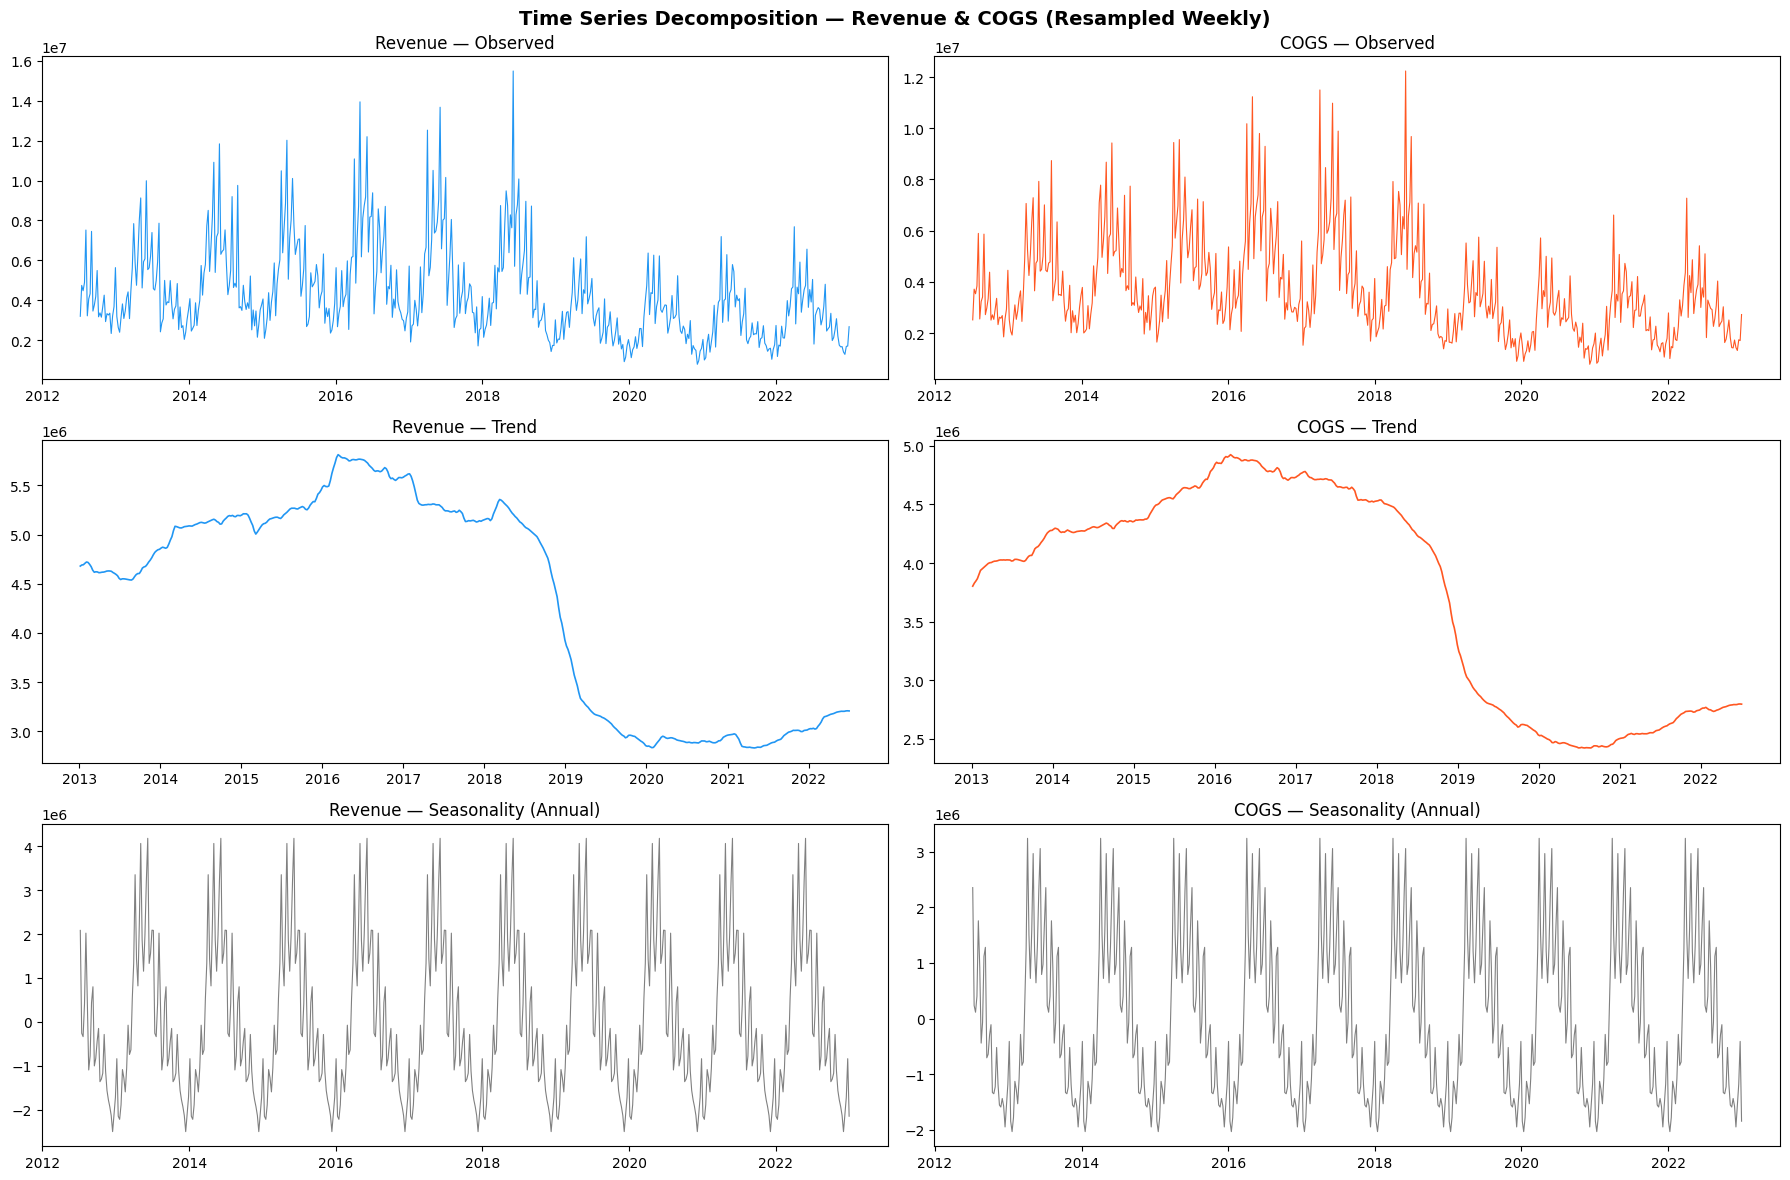


📌 Insight: Quan sát trend tăng dần theo năm và chu kỳ mùa vụ rõ ràng.


In [56]:
# ============================================================
# 4.2.1 — PHÂN RÃ CHUỖI THỜI GIAN (Decomposition)
# ============================================================
# Mục đích:
# - Tách chuỗi thành Trend + Seasonal + Residual
# - Xác nhận có tính mùa vụ 7 ngày (tuần) hay không

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Time Series Decomposition — Revenue & COGS (Resampled Weekly)', fontsize=14, fontweight='bold')

for col, color, col_idx in [('Revenue', COLOR_REV, 0), ('COGS', COLOR_COGS, 1)]:
    # Resample tuần để decomposition ổn định hơn
    series_weekly = df_sales.set_index('Date')[col].resample('W').mean()
    decomp = seasonal_decompose(series_weekly.dropna(), model='additive', period=52)
    
    axes[0, col_idx].plot(series_weekly.index, series_weekly.values, color=color, linewidth=0.8)
    axes[0, col_idx].set_title(f'{col} — Observed')
    
    axes[1, col_idx].plot(decomp.trend.index, decomp.trend.values, color=color, linewidth=1.2)
    axes[1, col_idx].set_title(f'{col} — Trend')
    
    axes[2, col_idx].plot(decomp.seasonal.index, decomp.seasonal.values, color='gray', linewidth=0.8)
    axes[2, col_idx].set_title(f'{col} — Seasonality (Annual)')

plt.tight_layout()
plt.show()
print('\n📌 Insight: Quan sát trend tăng dần theo năm và chu kỳ mùa vụ rõ ràng.')

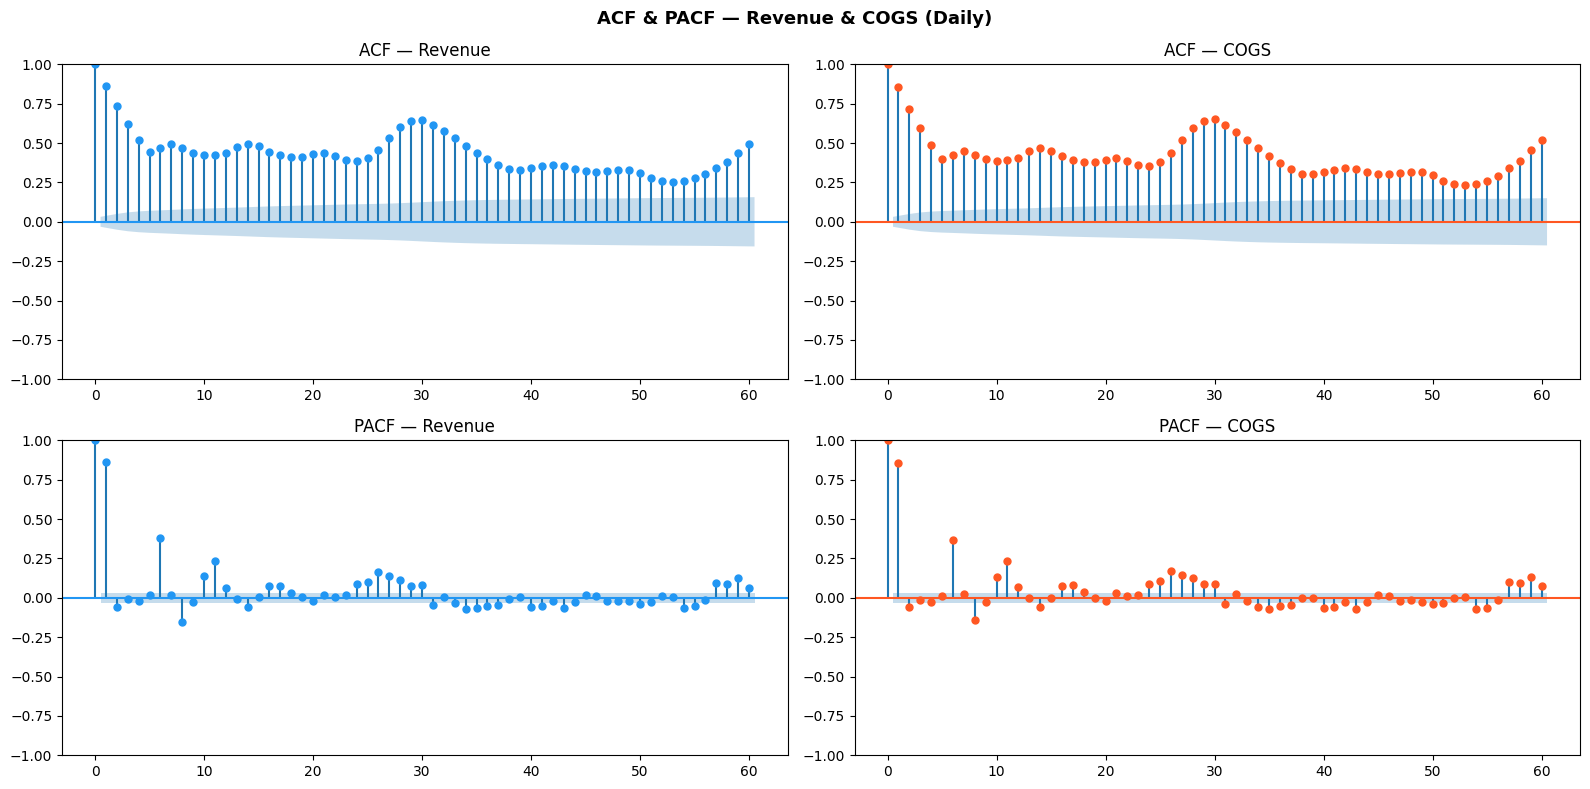


📌 Insight: Lag 1, 7, 14, 30, 365 thường có tương quan cao trong dữ liệu thương mại điện tử.


In [57]:
# ============================================================
# 4.2.2 — ACF / PACF (Tương quan chuỗi)
# ============================================================
# Mục đích:
# - ACF: xác định lag nào tương quan với hiện tại
# - PACF: xác định lag độc lập nào quan trọng nhất
# → Kết quả này quyết định lag features cần tạo trong 4.3

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('ACF & PACF — Revenue & COGS (Daily)', fontsize=13, fontweight='bold')

for i, col in enumerate(['Revenue', 'COGS']):
    series = df_sales[col].dropna()
    plot_acf(series,  lags=60, ax=axes[0, i], title=f'ACF — {col}',  color=COLOR_REV if col=='Revenue' else COLOR_COGS)
    plot_pacf(series, lags=60, ax=axes[1, i], title=f'PACF — {col}', color=COLOR_REV if col=='Revenue' else COLOR_COGS)

plt.tight_layout()
plt.show()
print('\n📌 Insight: Lag 1, 7, 14, 30, 365 thường có tương quan cao trong dữ liệu thương mại điện tử.')

In [58]:
# ============================================================
# 4.2.3 — KIỂM TRA TÍNH DỪNG (ADF Test)
# ============================================================
# Mục đích:
# - Augmented Dickey-Fuller test: chuỗi có unit root không?
# - Nếu p-value < 0.05 → chuỗi dừng → có thể dùng trực tiếp
# - Nếu không dừng → cần lấy sai phân hoặc log transform

for col in ['Revenue', 'COGS']:
    result = adfuller(df_sales[col].dropna(), autolag='AIC')
    print(f'=== ADF Test — {col} ===')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Kết luận      : {"✅ Chuỗi DỪNG" if result[1] < 0.05 else "⚠️ Chuỗi KHÔNG DỪNG — cân nhắc log/diff"}')
    print()

=== ADF Test — Revenue ===
  ADF Statistic : -2.5250
  p-value       : 0.1095
  Kết luận      : ⚠️ Chuỗi KHÔNG DỪNG — cân nhắc log/diff

=== ADF Test — COGS ===
  ADF Statistic : -2.4481
  p-value       : 0.1286
  Kết luận      : ⚠️ Chuỗi KHÔNG DỪNG — cân nhắc log/diff



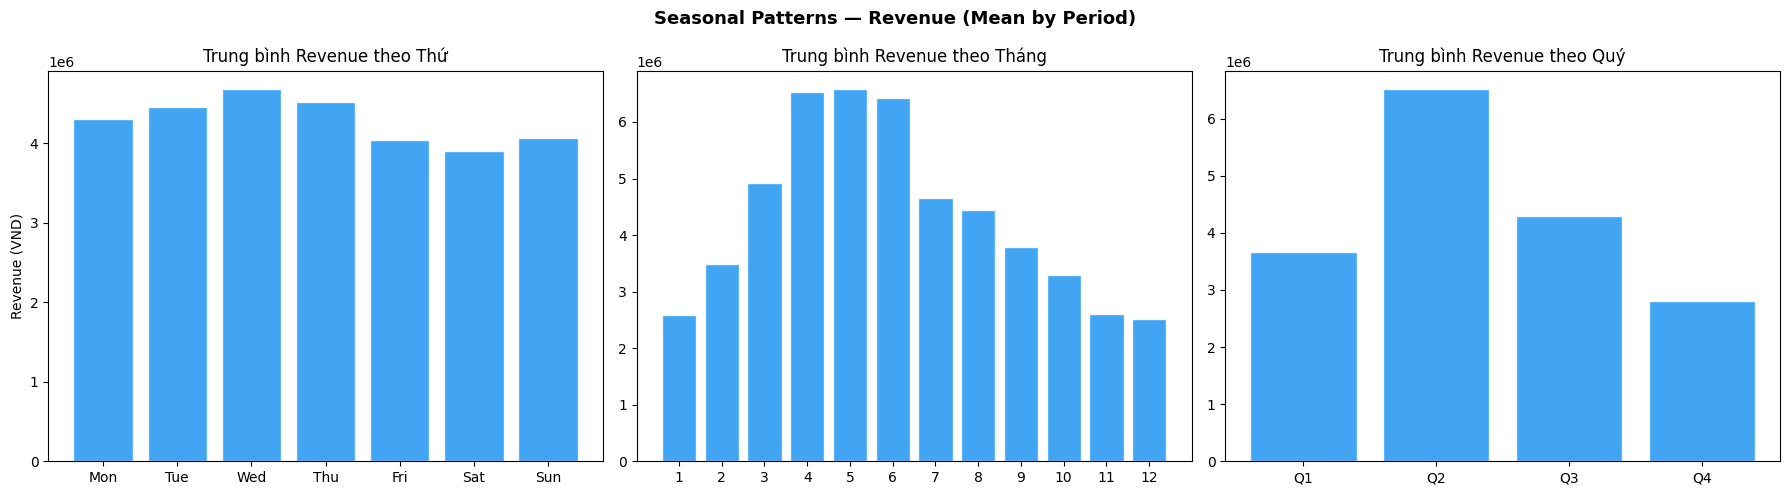


📌 Insight: Xác định đỉnh doanh thu theo tháng/quý để tạo holiday/peak-season features.


In [59]:
# ============================================================
# 4.2.4 — PHÂN TÍCH MÙA VỤ CHI TIẾT
# ============================================================
# Mục đích:
# - Xác nhận pattern theo ngày trong tuần, tháng, quý
# - Các pattern này sẽ trở thành features quan trọng

df_eda = df_sales.copy()
df_eda['DayOfWeek']  = df_eda['Date'].dt.dayofweek
df_eda['Month']      = df_eda['Date'].dt.month
df_eda['Quarter']    = df_eda['Date'].dt.quarter
df_eda['Year']       = df_eda['Date'].dt.year
DOW_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonal Patterns — Revenue (Mean by Period)', fontsize=13, fontweight='bold')

# Revenue theo ngày trong tuần
dow_avg = df_eda.groupby('DayOfWeek')['Revenue'].mean()
axes[0].bar(DOW_LABELS, dow_avg.values, color=COLOR_REV, edgecolor='white', alpha=0.85)
axes[0].set_title('Trung bình Revenue theo Thứ')
axes[0].set_ylabel('Revenue (VND)')

# Revenue theo tháng
month_avg = df_eda.groupby('Month')['Revenue'].mean()
axes[1].bar(range(1, 13), month_avg.values, color=COLOR_REV, edgecolor='white', alpha=0.85)
axes[1].set_title('Trung bình Revenue theo Tháng')
axes[1].set_xticks(range(1, 13))

# Revenue theo quý
q_avg = df_eda.groupby('Quarter')['Revenue'].mean()
axes[2].bar(['Q1','Q2','Q3','Q4'], q_avg.values, color=COLOR_REV, edgecolor='white', alpha=0.85)
axes[2].set_title('Trung bình Revenue theo Quý')

plt.tight_layout()
plt.show()
print('\n📌 Insight: Xác định đỉnh doanh thu theo tháng/quý để tạo holiday/peak-season features.')

## **4.3 Feature Engineering**

> **Chiến lược Feature Engineering** cho bài toán Time Series với ML:
>
> | Nhóm Feature | Ví dụ | Lý do |
> |---|---|---|
> | **Lag Features** | `lag_1`, `lag_7`, `lag_30`, `lag_365` | Capture autocorrelation trực tiếp |
> | **Rolling Stats** | `rolling_mean_7`, `rolling_std_30` | Smooth noise, capture local trend |
> | **Calendar** | `day_of_week`, `month`, `is_weekend` | Mùa vụ tuần/tháng |
> | **Fourier Terms** | `sin/cos` của chu kỳ 7, 30, 365 | Mùa vụ liên tục (smooth) |
> | **Vietnamese Holidays** | `tet_flag`, `national_day_flag` | Đỉnh bất thường có thể giải thích |
> | **Trend** | `days_since_start`, `log(t)` | Long-term growth |
> | **Exogenous** | `sessions`, `page_views` | Web traffic dự báo demand |
> | **COGS Ratio** | `cogs_revenue_ratio` | Quan hệ Revenue↔COGS ổn định |

In [60]:
# ============================================================
# 4.3.1 — HÀM TẠO FEATURES
# ============================================================
# Thiết kế dạng hàm để dùng lại cho cả train và test

def create_features(df: pd.DataFrame, target: str, horizon: int = 0) -> pd.DataFrame:
    """
    Tạo toàn bộ features cho mô hình dự báo time series.
    
    Parameters
    ----------
    df      : DataFrame với cột 'Date' và target (Revenue/COGS)
    target  : Tên cột mục tiêu
    horizon : Số bước dự báo tối thiểu (để tạo lag an toàn)
    
    Returns
    -------
    DataFrame với tất cả features
    """
    df = df.copy()
    df = df.sort_values('Date').reset_index(drop=True)
    
    # -------------------------------------------------------
    # A. CALENDAR FEATURES
    # -------------------------------------------------------
    df['day_of_week']       = df['Date'].dt.dayofweek          # 0=Mon...6=Sun
    df['day_of_month']      = df['Date'].dt.day
    df['day_of_year']       = df['Date'].dt.dayofyear
    df['month']             = df['Date'].dt.month
    df['quarter']           = df['Date'].dt.quarter
    df['year']              = df['Date'].dt.year
    df['week_of_year']      = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend']        = (df['Date'].dt.dayofweek >= 5).astype(int)
    df['is_month_start']    = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end']      = df['Date'].dt.is_month_end.astype(int)
    df['is_quarter_start']  = df['Date'].dt.is_quarter_start.astype(int)
    df['is_quarter_end']    = df['Date'].dt.is_quarter_end.astype(int)
    df['is_year_end']       = (df['Date'].dt.month == 12).astype(int)
    
    # -------------------------------------------------------
    # B. TREND FEATURE
    # -------------------------------------------------------
    t0 = df['Date'].min()
    df['days_since_start']  = (df['Date'] - t0).dt.days
    df['log_trend']         = np.log1p(df['days_since_start'])
    
    # -------------------------------------------------------
    # C. FOURIER FEATURES (mùa vụ liên tục)
    # -------------------------------------------------------
    # Chu kỳ: 7 ngày (tuần), 30.44 ngày (tháng), 365.25 ngày (năm)
    for period, label in [(7, 'week'), (30.44, 'month'), (365.25, 'year')]:
        for k in [1, 2]:  # k harmonics
            df[f'sin_{label}_k{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / period)
            df[f'cos_{label}_k{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / period)
    
    # -------------------------------------------------------
    # D. VIETNAMESE HOLIDAYS / PEAK SEASONS
    # -------------------------------------------------------
    month_day = df['Date'].dt.month * 100 + df['Date'].dt.day
    
    # Tết Nguyên Đán ≈ 10/1 → 20/2 (âm lịch, xấp xỉ dương lịch)
    df['is_tet_season'] = (
        ((df['month'] == 1) & (df['day_of_month'] >= 10)) |
        ((df['month'] == 2) & (df['day_of_month'] <= 20))
    ).astype(int)
    
    # 30/4 + 1/5 nghỉ lễ
    df['is_labor_day_season']  = ((df['month'] == 4) & (df['day_of_month'] >= 28) |
                                  (df['month'] == 5) & (df['day_of_month'] <= 3)).astype(int)
    
    # 2/9 Quốc khánh
    df['is_national_day']      = ((df['month'] == 9) & (df['day_of_month'].between(1, 4))).astype(int)
    
    # 11/11, 12/12 — Sale season (Black Friday VN)
    df['is_sale_11_11']        = ((df['month'] == 11) & (df['day_of_month'].between(9, 13))).astype(int)
    df['is_sale_12_12']        = ((df['month'] == 12) & (df['day_of_month'].between(10, 14))).astype(int)
    
    # Cuối năm bùng nổ mua sắm (15/12 → 31/12)
    df['is_yearend_shopping']  = ((df['month'] == 12) & (df['day_of_month'] >= 15)).astype(int)
    
    # Mùa hè (6–8)
    df['is_summer']            = df['month'].isin([6, 7, 8]).astype(int)

    # -------------------------------------------------------
    # E. LAG FEATURES
    # -------------------------------------------------------
    # Sử dụng min lag = horizon để tránh data leakage
    min_lag = max(1, horizon)
    lag_list = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 30, 60, 90, 182, 365]
    lag_list = [l for l in lag_list if l >= min_lag]

    for lag in lag_list:
        df[f'lag_{lag}'] = df[target].shift(lag)
    
    # -------------------------------------------------------
    # F. ROLLING STATISTICS
    # -------------------------------------------------------
    # Dùng min_periods để tránh NaN quá nhiều ở đầu
    for window in [7, 14, 30, 60, 90, 365]:
        roll = df[target].shift(min_lag).rolling(window=window, min_periods=max(1, window//2))
        df[f'rolling_mean_{window}']  = roll.mean()
        df[f'rolling_std_{window}']   = roll.std()
        df[f'rolling_max_{window}']   = roll.max()
        df[f'rolling_min_{window}']   = roll.min()
    
    # -------------------------------------------------------
    # G. DIFF / MOMENTUM FEATURES
    # -------------------------------------------------------
    df[f'diff_1']   = df[target].diff(1).shift(min_lag)
    df[f'diff_7']   = df[target].diff(7).shift(min_lag)
    df[f'diff_30']  = df[target].diff(30).shift(min_lag)
    
    # YoY growth (so với cùng kỳ năm ngoái)
    df['yoy_ratio'] = (df[target].shift(min_lag) / 
                       df[target].shift(365 + min_lag).replace(0, np.nan))
    
    return df


print('✅ Hàm create_features đã sẵn sàng')

✅ Hàm create_features đã sẵn sàng


In [61]:
# ============================================================
# 4.3.2 — THÊM EXOGENOUS FEATURES (Web Traffic)
# ============================================================
# Mục đích:
# - Gộp dữ liệu web traffic vào sales theo ngày
# - Web traffic là leading indicator — tăng trước khi Revenue tăng

def add_exogenous_features(df_main: pd.DataFrame, df_traffic: pd.DataFrame) -> pd.DataFrame:
    """
    Gộp web traffic vào bảng sales.
    Dùng lag 1 ngày để tránh data leakage (traffic hôm nay → revenue ngày mai)
    """
    # Tổng hợp traffic theo ngày (nhiều nguồn → 1 dòng/ngày)
    traffic_daily = df_traffic.groupby('Date').agg(
        sessions           = ('sessions', 'sum'),
        unique_visitors    = ('unique_visitors', 'sum'),
        page_views         = ('page_views', 'sum'),
        bounce_rate        = ('bounce_rate', 'mean'),
        avg_session_dur    = ('avg_session_duration_sec', 'mean')
    ).reset_index()
    
    # Lag 1 ngày để tránh leakage
    traffic_daily['sessions_lag1']        = traffic_daily['sessions'].shift(1)
    traffic_daily['page_views_lag1']      = traffic_daily['page_views'].shift(1)
    traffic_daily['unique_visitors_lag1'] = traffic_daily['unique_visitors'].shift(1)
    
    # Merge
    df_main = df_main.merge(
        traffic_daily[['Date', 'sessions_lag1', 'page_views_lag1', 'unique_visitors_lag1']],
        on='Date', how='left'
    )
    
    # Điền missing bằng median (trong test period có thể không có traffic data)
    for col in ['sessions_lag1', 'page_views_lag1', 'unique_visitors_lag1']:
        df_main[col] = df_main[col].fillna(df_main[col].median())
    
    return df_main


print('✅ Hàm add_exogenous_features đã sẵn sàng')

✅ Hàm add_exogenous_features đã sẵn sàng


In [62]:
# ============================================================
# 4.3.3 — THÊM PROMO FEATURES
# ============================================================
# Mục đích:
# - Đếm số lượng chiến dịch đang hoạt động mỗi ngày
# - Khuyến mãi là driver quan trọng của Revenue spikes

def add_promo_features(df_main: pd.DataFrame, df_promo: pd.DataFrame) -> pd.DataFrame:
    """
    Tính số chiến dịch khuyến mãi đang active mỗi ngày.
    """
    all_dates = df_main['Date'].sort_values().unique()
    
    promo_counts = []
    for dt in all_dates:
        active = df_promo[
            (df_promo['start_date'] <= dt) & (df_promo['end_date'] >= dt)
        ]
        promo_counts.append({'Date': dt, 'active_promos': len(active)})
    
    df_promo_daily = pd.DataFrame(promo_counts)
    df_main = df_main.merge(df_promo_daily, on='Date', how='left')
    df_main['active_promos'] = df_main['active_promos'].fillna(0)
    
    return df_main


print('✅ Hàm add_promo_features đã sẵn sàng')

✅ Hàm add_promo_features đã sẵn sàng


In [63]:
# ============================================================
# 4.3.4 — XÂY DỰNG FULL FEATURE TABLE
# ============================================================
# Mục đích:
# - Kết hợp toàn bộ features cho Revenue và COGS
# - Chuẩn bị tập dữ liệu sẵn sàng cho modeling

# Bước 1: Tạo features cho Revenue (lag tối thiểu = 1 ngày)
df_rev = create_features(df_sales[['Date', 'Revenue']].copy(), target='Revenue', horizon=1)

# Bước 2: Tạo features cho COGS
df_cogs = create_features(df_sales[['Date', 'COGS']].copy(), target='COGS', horizon=1)

# Bước 3: Thêm features từ COGS vào Revenue table (và ngược lại) — cross-series features
# COGS t-1 là predictor tốt cho Revenue t vì chúng cùng trend
df_rev['cogs_lag1']          = df_cogs['COGS'].shift(1).values
df_rev['cogs_rolling7']      = df_cogs['COGS'].shift(1).rolling(7).mean().values
df_rev['cogs_rev_ratio_lag1'] = (df_cogs['COGS'].shift(1) / df_sales['Revenue'].shift(1)).values

# Tương tự cho COGS model
df_cogs['rev_lag1']          = df_sales['Revenue'].shift(1).values
df_cogs['rev_rolling7']      = df_sales['Revenue'].shift(1).rolling(7).mean().values

# Bước 4: Thêm exogenous features
df_rev  = add_exogenous_features(df_rev,  df_traffic)
df_cogs = add_exogenous_features(df_cogs, df_traffic)

# Bước 5: Thêm promo features
df_rev  = add_promo_features(df_rev,  df_promo)
df_cogs = add_promo_features(df_cogs, df_promo)

print('✅ Feature Engineering hoàn tất')
print(f'Revenue  feature table: {df_rev.shape[1]} cột, {df_rev.shape[0]:,} hàng')
print(f'COGS     feature table: {df_cogs.shape[1]} cột, {df_cogs.shape[0]:,} hàng')
print('\nMẫu features (Revenue):')
print(df_rev.columns.tolist())

✅ Feature Engineering hoàn tất
Revenue  feature table: 86 cột, 3,833 hàng
COGS     feature table: 85 cột, 3,833 hàng

Mẫu features (Revenue):
['Date', 'Revenue', 'day_of_week', 'day_of_month', 'day_of_year', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_end', 'days_since_start', 'log_trend', 'sin_week_k1', 'cos_week_k1', 'sin_week_k2', 'cos_week_k2', 'sin_month_k1', 'cos_month_k1', 'sin_month_k2', 'cos_month_k2', 'sin_year_k1', 'cos_year_k1', 'sin_year_k2', 'cos_year_k2', 'is_tet_season', 'is_labor_day_season', 'is_national_day', 'is_sale_11_11', 'is_sale_12_12', 'is_yearend_shopping', 'is_summer', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_30', 'lag_60', 'lag_90', 'lag_182', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14', 'rolling_mean_

## **4.4 Train / Validation Split (Walk-Forward)**

> Để tránh **look-ahead bias**, dùng **Walk-Forward Validation**:
> - Train: 2012 → 2021
> - Validation: 2022 (1 năm — giống test set về khoảng cách)
> - Test dự báo: 2023 → 2024-07

In [64]:
# ============================================================
# 4.4 TRAIN / VALIDATION SPLIT
# ============================================================

TRAIN_END   = '2021-12-31'
VALID_START = '2022-01-01'
VALID_END   = '2022-12-31'

def split_data(df: pd.DataFrame, target: str):
    """
    Split theo thời gian, loại bỏ NaN từ lag features.
    Trả về (X_train, y_train, X_val, y_val, feature_cols)
    """
    # Các cột không phải feature
    non_feature_cols = ['Date', 'Revenue', 'COGS']
    feature_cols = [c for c in df.columns if c not in non_feature_cols]
    
    df_train = df[df['Date'] <= TRAIN_END].copy()
    df_val   = df[(df['Date'] >= VALID_START) & (df['Date'] <= VALID_END)].copy()
    
    # Loại bỏ hàng có NaN trong features
    df_train = df_train.dropna(subset=feature_cols)
    df_val   = df_val.dropna(subset=feature_cols)
    
    X_train = df_train[feature_cols]
    y_train = df_train[target]
    X_val   = df_val[feature_cols]
    y_val   = df_val[target]
    
    return X_train, y_train, X_val, y_val, feature_cols


# Revenue
X_train_rev, y_train_rev, X_val_rev, y_val_rev, feature_cols_rev = split_data(df_rev, 'Revenue')

# COGS
X_train_cogs, y_train_cogs, X_val_cogs, y_val_cogs, feature_cols_cogs = split_data(df_cogs, 'COGS')

print('=== TRAIN/VAL SPLIT ===')
print(f'Revenue  — Train: {X_train_rev.shape[0]:,} rows | Val: {X_val_rev.shape[0]:,} rows | Features: {X_train_rev.shape[1]}')
print(f'COGS     — Train: {X_train_cogs.shape[0]:,} rows | Val: {X_val_cogs.shape[0]:,} rows | Features: {X_train_cogs.shape[1]}')

=== TRAIN/VAL SPLIT ===
Revenue  — Train: 3,102 rows | Val: 365 rows | Features: 84
COGS     — Train: 3,102 rows | Val: 365 rows | Features: 83


## **4.5 Baseline Models**

> Trước khi train model phức tạp, luôn thiết lập **baseline** để so sánh.  
> Nếu model ML không tốt hơn baseline → có vấn đề về data/feature.

In [69]:
# ============================================================
# 4.5 BASELINE MODELS
# ============================================================
# 1. Naive: dự báo = giá trị hôm qua (lag_1)
# 2. Seasonal Naive: dự báo = giá trị cùng ngày tuần trước (lag_7)
# 3. 30-day Rolling Mean: trung bình 30 ngày gần nhất

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# Lấy dữ liệu validation để test baseline
val_data = df_rev[(df_rev['Date'] >= VALID_START) & (df_rev['Date'] <= VALID_END)].copy()

baselines = {
    'Naive (lag_1)':         val_data['lag_1'].ffill(),
    'Seasonal Naive (lag_7)': val_data['lag_7'].ffill(),
    'Rolling Mean 30d':      val_data['rolling_mean_30'].ffill(),
}

y_val_arr = val_data['Revenue'].values

print('=== BASELINE PERFORMANCE ON VALIDATION SET (Revenue) ===')
print(f'{"Model":<30} {"RMSE":>15} {"MAE":>15} {"MAPE":>10}')
print('-' * 72)
for name, pred in baselines.items():
    pred_arr = pred.values
    valid_mask = ~np.isnan(pred_arr)
    r = rmse(y_val_arr[valid_mask], pred_arr[valid_mask])
    m = mae(y_val_arr[valid_mask], pred_arr[valid_mask])
    mp = mape(y_val_arr[valid_mask], pred_arr[valid_mask])
    print(f'{name:<30} {r:>15,.2f} {m:>15,.2f} {mp:>9.2f}%')

print('\n📌 Mục tiêu: Model ML phải tốt hơn Seasonal Naive đáng kể.')

=== BASELINE PERFORMANCE ON VALIDATION SET (Revenue) ===
Model                                     RMSE             MAE       MAPE
------------------------------------------------------------------------
Naive (lag_1)                     1,077,205.68      724,145.78     27.53%
Seasonal Naive (lag_7)            1,903,430.94    1,339,897.20     51.83%
Rolling Mean 30d                  1,339,324.11      953,596.57     35.59%

📌 Mục tiêu: Model ML phải tốt hơn Seasonal Naive đáng kể.


## **4.6 LightGBM Model**

In [70]:
# ============================================================
# 4.6 LIGHTGBM — DEFAULT PARAMS
# ============================================================
# Mục đích:
# - Train LightGBM với params khởi đầu tốt
# - Đánh giá trên validation set
# - Làm benchmark trước khi tuning

LGBM_DEFAULT_PARAMS = {
    'objective'        : 'regression',
    'metric'           : 'rmse',
    'boosting_type'    : 'gbdt',
    'n_estimators'     : 2000,
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'max_depth'        : -1,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'n_jobs'           : -1,
    'random_state'     : SEED,
    'verbose'          : -1,
}

def train_lgbm(X_train, y_train, X_val, y_val, params: dict, label: str = '') -> lgb.LGBMRegressor:
    """
    Train LightGBM với early stopping.
    """
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )
    
    y_pred = model.predict(X_val)
    print(f'\n=== LightGBM {label} Validation ===')
    print(f'  Best iteration : {model.best_iteration_}')
    print(f'  RMSE           : {rmse(y_val, y_pred):,.2f}')
    print(f'  MAE            : {mae(y_val, y_pred):,.2f}')
    print(f'  MAPE           : {mape(y_val, y_pred):.2f}%')
    
    return model


# Train Revenue model
lgbm_rev = train_lgbm(
    X_train_rev, y_train_rev,
    X_val_rev,   y_val_rev,
    LGBM_DEFAULT_PARAMS.copy(), label='Revenue'
)

# Train COGS model
lgbm_cogs = train_lgbm(
    X_train_cogs, y_train_cogs,
    X_val_cogs,   y_val_cogs,
    LGBM_DEFAULT_PARAMS.copy(), label='COGS'
)

[200]	valid_0's rmse: 750913

=== LightGBM Revenue Validation ===
  Best iteration : 214
  RMSE           : 749,916.27
  MAE            : 547,150.41
  MAPE           : 19.53%
[200]	valid_0's rmse: 654113

=== LightGBM COGS Validation ===
  Best iteration : 144
  RMSE           : 650,182.79
  MAE            : 474,807.42
  MAPE           : 19.57%


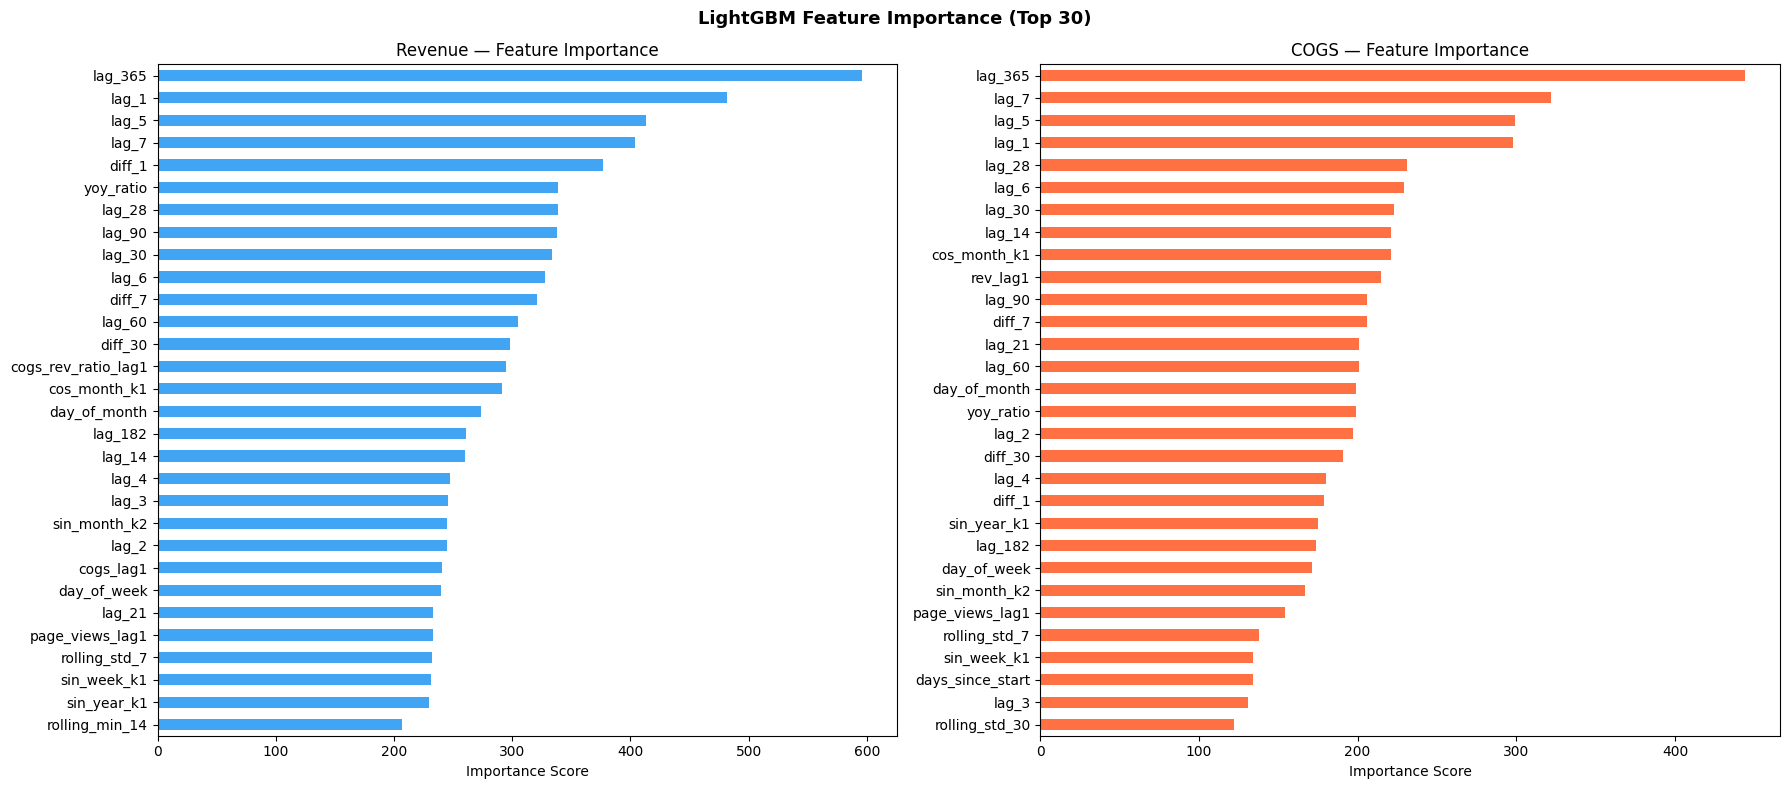

In [71]:
# ============================================================
# 4.6.1 — FEATURE IMPORTANCE
# ============================================================
# Mục đích:
# - Xác định features quan trọng nhất
# - Loại bỏ features kém hiệu quả để giảm overfitting

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('LightGBM Feature Importance (Top 30)', fontsize=13, fontweight='bold')

for ax, model, label, color in [
    (axes[0], lgbm_rev,  'Revenue', COLOR_REV),
    (axes[1], lgbm_cogs, 'COGS',    COLOR_COGS)
]:
    imp = pd.Series(
        model.feature_importances_,
        index=model.feature_name_
    ).sort_values(ascending=True).tail(30)
    
    imp.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'{label} — Feature Importance')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## **4.7 XGBoost Model**

In [72]:
# ============================================================
# 4.7 XGBOOST — DEFAULT PARAMS
# ============================================================

XGB_DEFAULT_PARAMS = {
    'objective'       : 'reg:squarederror',
    'eval_metric'     : 'rmse',
    'n_estimators'    : 2000,
    'learning_rate'   : 0.05,
    'max_depth'       : 6,
    'min_child_weight': 5,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'n_jobs'          : -1,
    'random_state'    : SEED,
    'early_stopping_rounds': 100,
    'verbosity'       : 0,
}

def train_xgb(X_train, y_train, X_val, y_val, params: dict, label: str = '') -> xgb.XGBRegressor:
    """
    Train XGBoost với early stopping.
    """
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=200
    )
    
    y_pred = model.predict(X_val)
    print(f'\n=== XGBoost {label} Validation ===')
    print(f'  Best iteration : {model.best_iteration}')
    print(f'  RMSE           : {rmse(y_val, y_pred):,.2f}')
    print(f'  MAE            : {mae(y_val, y_pred):,.2f}')
    print(f'  MAPE           : {mape(y_val, y_pred):.2f}%')
    
    return model


# Train Revenue model
xgb_rev = train_xgb(
    X_train_rev, y_train_rev,
    X_val_rev,   y_val_rev,
    XGB_DEFAULT_PARAMS.copy(), label='Revenue'
)

# Train COGS model
xgb_cogs = train_xgb(
    X_train_cogs, y_train_cogs,
    X_val_cogs,   y_val_cogs,
    XGB_DEFAULT_PARAMS.copy(), label='COGS'
)

[0]	validation_0-rmse:1951405.31737
[200]	validation_0-rmse:745915.75212
[305]	validation_0-rmse:748605.79336

=== XGBoost Revenue Validation ===
  Best iteration : 205
  RMSE           : 744,778.23
  MAE            : 539,253.01
  MAPE           : 19.35%
[0]	validation_0-rmse:1687829.94794
[200]	validation_0-rmse:646277.13582
[355]	validation_0-rmse:643386.03025

=== XGBoost COGS Validation ===
  Best iteration : 255
  RMSE           : 642,392.90
  MAE            : 470,873.23
  MAPE           : 19.73%


## **4.8 Hyperparameter Tuning với Optuna**

> **Optuna** dùng thuật toán **TPE (Tree-structured Parzen Estimator)** — thông minh hơn Grid Search:
> - Học từ kết quả các trial trước
> - Tập trung vào vùng tham số có triển vọng
> - Nhanh hơn ~10× so với Grid Search

In [73]:
# ============================================================
# 4.8 OPTUNA TUNING — LIGHTGBM (REVENUE)
# ============================================================
# Mục đích:
# - Tìm hyperparameters tối ưu cho LightGBM
# - Dùng 50 trials với TPE sampler
# - Tối ưu hóa RMSE trên validation set

N_TRIALS = 50   # Tăng lên 100+ để kết quả tốt hơn nếu có thời gian

def objective_lgbm_rev(trial):
    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'boosting_type'    : trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'n_estimators'     : 2000,
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 255),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq'     : trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 1.0),
        'n_jobs'           : -1,
        'random_state'     : SEED,
        'verbose'          : -1,
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_rev, y_train_rev,
        eval_set=[(X_val_rev, y_val_rev)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    
    y_pred = model.predict(X_val_rev)
    return rmse(y_val_rev, y_pred)


print(f'🔍 Bắt đầu Optuna search cho Revenue LightGBM ({N_TRIALS} trials)...')
study_lgbm_rev = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED)
)
study_lgbm_rev.optimize(objective_lgbm_rev, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ Best RMSE (Revenue)  : {study_lgbm_rev.best_value:,.2f}')
print(f'Best Params:\n{json.dumps(study_lgbm_rev.best_params, indent=2)}')

🔍 Bắt đầu Optuna search cho Revenue LightGBM (50 trials)...


Best trial: 34. Best value: 730433: 100%|██████████| 50/50 [05:08<00:00,  6.16s/it]


✅ Best RMSE (Revenue)  : 730,432.76
Best Params:
{
  "boosting_type": "dart",
  "learning_rate": 0.08548818680026155,
  "num_leaves": 161,
  "max_depth": 5,
  "min_child_samples": 20,
  "feature_fraction": 0.5888199125946467,
  "bagging_fraction": 0.9679931209964301,
  "bagging_freq": 8,
  "reg_alpha": 0.8911713894980187,
  "reg_lambda": 0.002735566199465522,
  "min_split_gain": 0.815573702332922
}


In [74]:
# ============================================================
# OPTUNA TUNING — LIGHTGBM (COGS)
# ============================================================

def objective_lgbm_cogs(trial):
    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'boosting_type'    : trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'n_estimators'     : 2000,
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 255),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq'     : trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'n_jobs'           : -1,
        'random_state'     : SEED,
        'verbose'          : -1,
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_cogs, y_train_cogs,
        eval_set=[(X_val_cogs, y_val_cogs)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    
    y_pred = model.predict(X_val_cogs)
    return rmse(y_val_cogs, y_pred)


print(f'🔍 Bắt đầu Optuna search cho COGS LightGBM ({N_TRIALS} trials)...')
study_lgbm_cogs = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED)
)
study_lgbm_cogs.optimize(objective_lgbm_cogs, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ Best RMSE (COGS)     : {study_lgbm_cogs.best_value:,.2f}')
print(f'Best Params:\n{json.dumps(study_lgbm_cogs.best_params, indent=2)}')

🔍 Bắt đầu Optuna search cho COGS LightGBM (50 trials)...


Best trial: 42. Best value: 629862: 100%|██████████| 50/50 [04:18<00:00,  5.17s/it]


✅ Best RMSE (COGS)     : 629,862.15
Best Params:
{
  "boosting_type": "dart",
  "learning_rate": 0.08899503010088701,
  "num_leaves": 114,
  "max_depth": 4,
  "min_child_samples": 57,
  "feature_fraction": 0.7646616688669847,
  "bagging_fraction": 0.5361252439375813,
  "bagging_freq": 6,
  "reg_alpha": 0.0015645186373645908,
  "reg_lambda": 4.584049307056165
}


In [75]:
# ============================================================
# TRAIN FINAL LGBM VỚI BEST PARAMS + RETRAIN TRÊN FULL DATA
# ============================================================
# Sau tuning, retrain trên toàn bộ train+val để tối đa dữ liệu

def train_final_lgbm(df_full, target, best_params, feature_cols, label=''):
    """
    Train lại trên full data (train+val) với best hyperparams.
    Số iterations = best_iteration * (train+val / train) để adjust.
    """
    df_train = df_full[df_full['Date'] <= VALID_END].copy().dropna(subset=feature_cols)
    X_full   = df_train[feature_cols]
    y_full   = df_train[target]
    
    params = {
        **best_params,
        'objective'    : 'regression',
        'metric'       : 'rmse',
        'n_estimators' : 3000,
        'n_jobs'       : -1,
        'random_state' : SEED,
        'verbose'      : -1,
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_full, y_full, callbacks=[lgb.log_evaluation(period=500)])
    print(f'✅ Final LGBM {label} trained on {len(X_full):,} samples')
    return model


lgbm_rev_final  = train_final_lgbm(df_rev,  'Revenue', study_lgbm_rev.best_params,  feature_cols_rev,  'Revenue')
lgbm_cogs_final = train_final_lgbm(df_cogs, 'COGS',    study_lgbm_cogs.best_params, feature_cols_cogs, 'COGS')

✅ Final LGBM Revenue trained on 3,467 samples
✅ Final LGBM COGS trained on 3,467 samples


## **4.9 Ensemble & Blending**

> Kết hợp nhiều mô hình giúp giảm variance và tăng robustness.
> Dùng **weighted average** với trọng số học từ validation performance.

In [76]:
# ============================================================
# 4.9 ENSEMBLE — WEIGHTED BLENDING (LightGBM + XGBoost)
# ============================================================
# Mục đích:
# - Kết hợp dự báo từ LightGBM (tuned) và XGBoost
# - Trọng số tối ưu dựa trên validation RMSE
# - Model nào có RMSE thấp hơn → trọng số cao hơn

def find_optimal_blend_weight(y_true, pred_a, pred_b, n_steps=100):
    """
    Tìm trọng số w tối ưu sao cho w*pred_a + (1-w)*pred_b có RMSE thấp nhất.
    """
    best_w, best_rmse = 0.5, float('inf')
    for w in np.linspace(0, 1, n_steps + 1):
        blended = w * pred_a + (1 - w) * pred_b
        r = rmse(y_true, blended)
        if r < best_rmse:
            best_rmse = r
            best_w = w
    return best_w, best_rmse


# Dự báo trên validation set
pred_lgbm_rev_val  = lgbm_rev.predict(X_val_rev)
pred_xgb_rev_val   = xgb_rev.predict(X_val_rev)
pred_lgbm_cogs_val = lgbm_cogs.predict(X_val_cogs)
pred_xgb_cogs_val  = xgb_cogs.predict(X_val_cogs)

# Tìm trọng số tối ưu
w_rev,  rmse_blend_rev  = find_optimal_blend_weight(y_val_rev,  pred_lgbm_rev_val,  pred_xgb_rev_val)
w_cogs, rmse_blend_cogs = find_optimal_blend_weight(y_val_cogs, pred_lgbm_cogs_val, pred_xgb_cogs_val)

print('=== ENSEMBLE RESULTS (Validation) ===')
print(f'Revenue  — LGBM: {rmse(y_val_rev,  pred_lgbm_rev_val):>12,.2f} | XGB: {rmse(y_val_rev,  pred_xgb_rev_val):>12,.2f} | Blend ({w_rev:.2f}): {rmse_blend_rev:>12,.2f}')
print(f'COGS     — LGBM: {rmse(y_val_cogs, pred_lgbm_cogs_val):>12,.2f} | XGB: {rmse(y_val_cogs, pred_xgb_cogs_val):>12,.2f} | Blend ({w_cogs:.2f}): {rmse_blend_cogs:>12,.2f}')

=== ENSEMBLE RESULTS (Validation) ===
Revenue  — LGBM:   749,916.27 | XGB:   744,778.23 | Blend (0.40):   740,665.16
COGS     — LGBM:   650,182.79 | XGB:   642,392.90 | Blend (0.31):   640,357.90


## **4.10 Evaluation & Error Analysis**

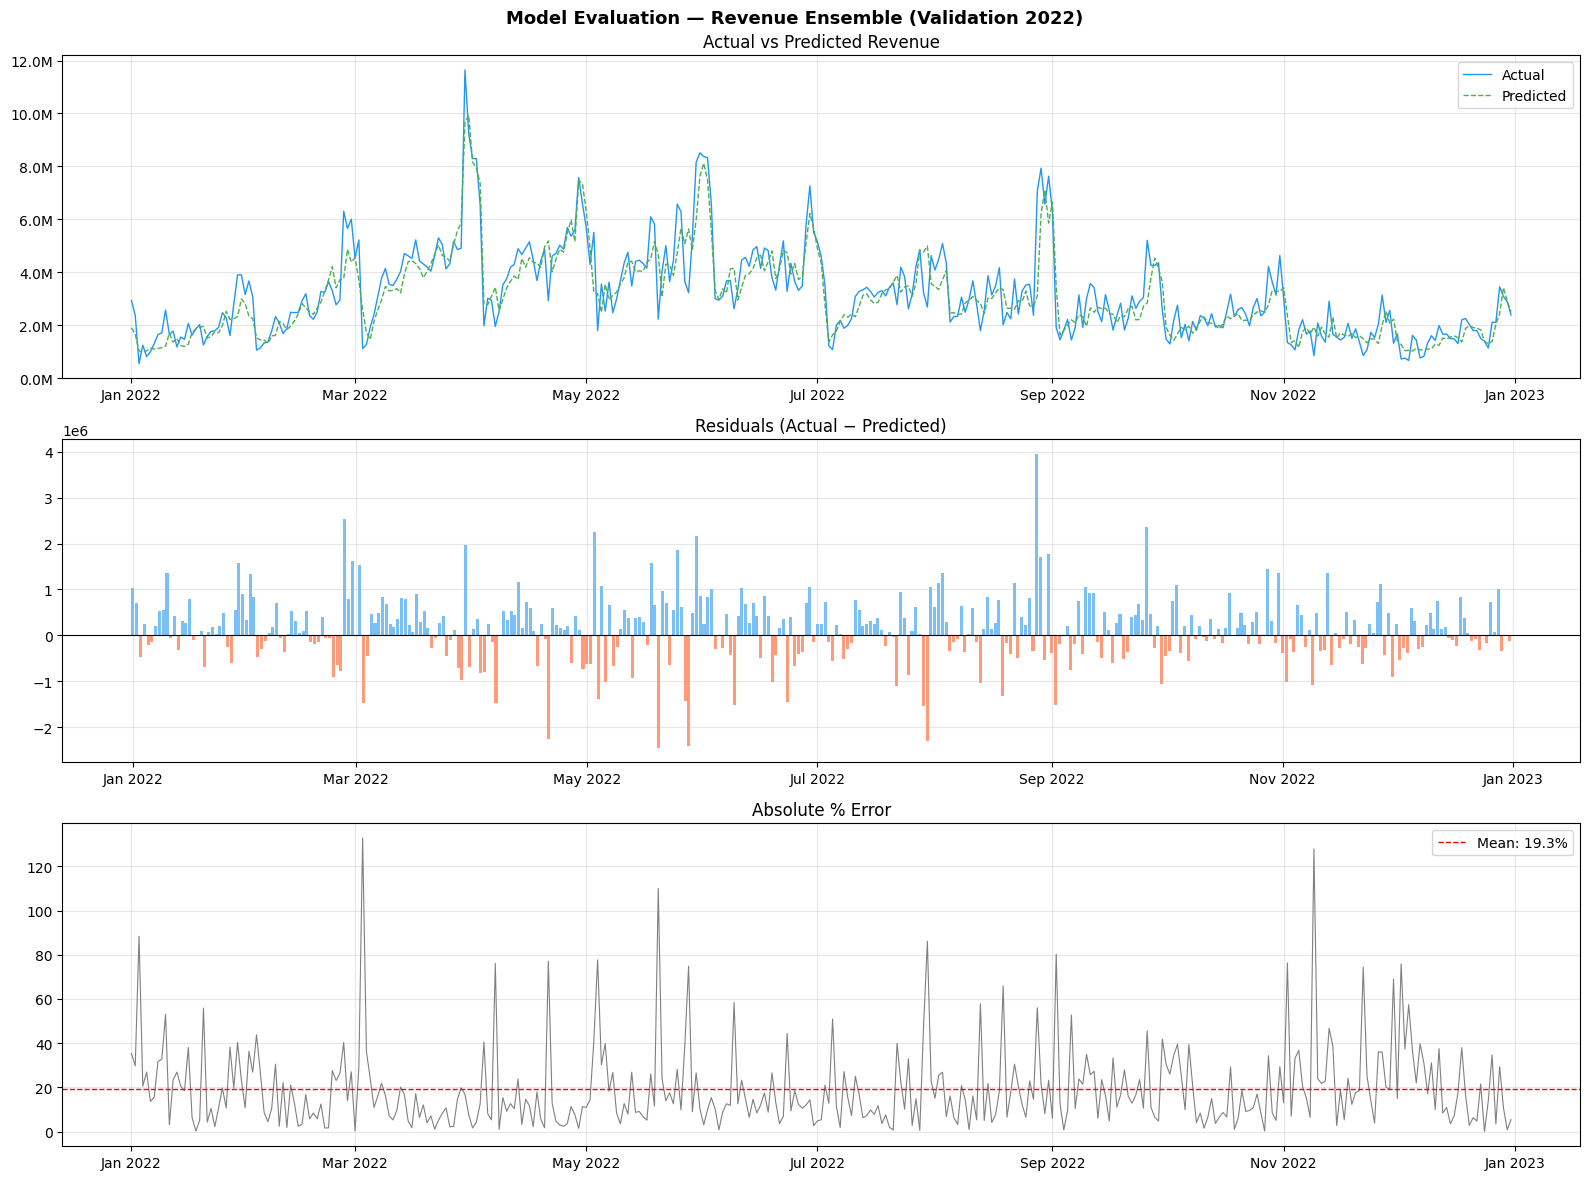


=== VALIDATION METRICS SUMMARY ===
RMSE :      740,665.16
MAE  :      539,060.23
MAPE :          19.32%

Top 10 ngày sai nhất:
      Date        Actual    Predicted     AbsError  PctError
2022-08-28  7,051,722.27 3,096,634.50 3,955,087.77     56.09
2022-02-26  6,304,749.98 3,760,266.22 2,544,483.76     40.36
2022-05-20  2,226,534.20 4,674,832.64 2,448,298.44    109.96
2022-05-28  3,223,975.84 5,635,963.16 2,411,987.32     74.81
2022-09-26  5,205,389.57 2,833,581.57 2,371,808.00     45.56
2022-07-30  2,682,461.47 4,992,260.87 2,309,799.40     86.11
2022-05-03  5,504,853.65 3,240,598.65 2,264,255.00     41.13
2022-04-21  2,926,459.00 5,182,104.09 2,255,645.09     77.08
2022-05-30  8,158,502.00 5,990,806.89 2,167,695.11     26.57
2022-03-30 11,643,208.73 9,675,080.10 1,968,128.63     16.90


In [77]:
# ============================================================
# 4.10.1 — PHÂN TÍCH LỖI THEO THỜI GIAN
# ============================================================
# Mục đích:
# - Xác định giai đoạn nào mô hình dự báo kém
# - Tìm pattern trong residuals để cải thiện model

pred_blend_rev_val = w_rev * pred_lgbm_rev_val + (1 - w_rev) * pred_xgb_rev_val

val_dates = df_rev[(df_rev['Date'] >= VALID_START) & 
                   (df_rev['Date'] <= VALID_END)]['Date'].values

df_eval = pd.DataFrame({
    'Date'     : val_dates[:len(y_val_rev)],
    'Actual'   : y_val_rev.values,
    'Predicted': pred_blend_rev_val,
    'Error'    : y_val_rev.values - pred_blend_rev_val,
    'AbsError' : np.abs(y_val_rev.values - pred_blend_rev_val),
    'PctError' : np.abs(y_val_rev.values - pred_blend_rev_val) / y_val_rev.values * 100
})

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Model Evaluation — Revenue Ensemble (Validation 2022)', fontsize=13, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0].plot(df_eval['Date'], df_eval['Actual'],    label='Actual',    color=COLOR_REV,  linewidth=1.0)
axes[0].plot(df_eval['Date'], df_eval['Predicted'], label='Predicted', color=COLOR_PRED, linewidth=1.0, linestyle='--')
axes[0].set_title('Actual vs Predicted Revenue')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Plot 2: Residuals
axes[1].bar(df_eval['Date'], df_eval['Error'], color=np.where(df_eval['Error'] >= 0, COLOR_REV, COLOR_COGS), alpha=0.6)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals (Actual − Predicted)')

# Plot 3: % Error
axes[2].plot(df_eval['Date'], df_eval['PctError'], color='gray', linewidth=0.8)
axes[2].axhline(df_eval['PctError'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df_eval["PctError"].mean():.1f}%')
axes[2].set_title('Absolute % Error')
axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== VALIDATION METRICS SUMMARY ===')
print(f'RMSE : {rmse(df_eval["Actual"], df_eval["Predicted"]):>15,.2f}')
print(f'MAE  : {mae(df_eval["Actual"], df_eval["Predicted"]):>15,.2f}')
print(f'MAPE : {mape(df_eval["Actual"], df_eval["Predicted"]):>14.2f}%')
print(f'\nTop 10 ngày sai nhất:')
print(df_eval.nlargest(10, 'AbsError')[['Date','Actual','Predicted','AbsError','PctError']].to_string(index=False))

## **4.11 Tạo File Dự báo (Generate Submission)**

> **Chiến lược dự báo**: Vì mô hình dùng lag features, ta cần **recursive forecasting**:
> 1. Dự báo ngày `t+1` → dùng kết quả này làm lag cho ngày `t+2` → ...
> 2. Đây là cách chính xác nhất cho multi-step ahead forecasting với lag-based models.

In [78]:
# ============================================================
# 4.11.1 — RECURSIVE FORECASTING ENGINE
# ============================================================
# Mục đích:
# - Dự báo từng ngày từ 2023-01-01 → 2024-07-01
# - Cập nhật lag features dựa trên dự báo ngày trước

def recursive_forecast(
    df_history   : pd.DataFrame,
    model_lgbm,
    model_xgb,
    blend_weight : float,
    target       : str,
    feature_cols : list,
    test_dates   : pd.DatetimeIndex,
    df_traffic   : pd.DataFrame = None,
    df_promo     : pd.DataFrame = None,
) -> np.ndarray:
    """
    Recursive multi-step forecasting.
    Mỗi bước dự báo ngày t, sau đó append vào lịch sử để dùng cho bước t+1.
    
    Returns: array dự báo với độ dài = len(test_dates)
    """
    predictions = []
    
    # Clone lịch sử để không làm ô nhiễm df gốc
    history = df_history.copy()
    
    for forecast_date in test_dates:
        # Tạo một hàng mới cho ngày cần dự báo
        new_row = pd.DataFrame({'Date': [forecast_date], target: [np.nan]})
        history_ext = pd.concat([history, new_row], ignore_index=True)
        
        # Tính lại features trên toàn bộ lịch sử mở rộng
        history_feat = create_features(history_ext, target=target, horizon=1)
        
        # Thêm exogenous features nếu có
        if df_traffic is not None:
            history_feat = add_exogenous_features(history_feat, df_traffic)
        if df_promo is not None:
            history_feat = add_promo_features(history_feat, df_promo)
        
        # Lấy hàng cuối cùng (ngày dự báo)
        row_to_predict = history_feat.iloc[[-1]]
        
        # Đảm bảo đủ feature_cols (điền NaN nếu thiếu cột)
        for col in feature_cols:
            if col not in row_to_predict.columns:
                row_to_predict[col] = 0
        
        X_pred = row_to_predict[feature_cols].fillna(0)
        
        # Dự báo ensemble
        pred_lgbm = model_lgbm.predict(X_pred)[0]
        pred_xgb  = model_xgb.predict(X_pred)[0]
        pred_final = blend_weight * pred_lgbm + (1 - blend_weight) * pred_xgb
        pred_final = max(pred_final, 0)  # Đảm bảo không âm
        
        predictions.append(pred_final)
        
        # Cập nhật lịch sử: điền giá trị dự báo vào hàng mới
        history = history_ext.copy()
        history.loc[history.index[-1], target] = pred_final
        
        # Giữ window ~1000 ngày để tránh memory quá lớn
        if len(history) > 4000:
            history = history.iloc[-4000:].reset_index(drop=True)
    
    return np.array(predictions)


print('✅ Recursive Forecast Engine sẵn sàng')

✅ Recursive Forecast Engine sẵn sàng


In [79]:
# ============================================================
# 4.11.2 — CHẠY DỰ BÁO CHO TOÀN BỘ TEST PERIOD
# ============================================================

# Lấy ngày cần dự báo từ submission template
test_dates = pd.to_datetime(df_submission_template['Date'].values)
print(f'📅 Test period: {test_dates[0].date()} → {test_dates[-1].date()} ({len(test_dates)} ngày)')

# Lịch sử Revenue (toàn bộ training data)
history_rev_full  = df_sales[['Date', 'Revenue']].copy()
history_cogs_full = df_sales[['Date', 'COGS']].copy()

# --- Dự báo Revenue ---
print('\n⏳ Đang dự báo Revenue...')
pred_revenue = recursive_forecast(
    df_history   = history_rev_full,
    model_lgbm   = lgbm_rev_final,
    model_xgb    = xgb_rev,
    blend_weight = w_rev,
    target       = 'Revenue',
    feature_cols = feature_cols_rev,
    test_dates   = test_dates,
    df_traffic   = df_traffic,
    df_promo     = df_promo,
)
print(f'  ✅ Revenue: {pred_revenue.min():,.0f} → {pred_revenue.max():,.0f} (mean: {pred_revenue.mean():,.0f})')

# --- Dự báo COGS ---
print('\n⏳ Đang dự báo COGS...')
pred_cogs = recursive_forecast(
    df_history   = history_cogs_full,
    model_lgbm   = lgbm_cogs_final,
    model_xgb    = xgb_cogs,
    blend_weight = w_cogs,
    target       = 'COGS',
    feature_cols = feature_cols_cogs,
    test_dates   = test_dates,
    df_traffic   = df_traffic,
    df_promo     = df_promo,
)
print(f'  ✅ COGS: {pred_cogs.min():,.0f} → {pred_cogs.max():,.0f} (mean: {pred_cogs.mean():,.0f})')

📅 Test period: 2023-01-01 → 2024-07-01 (548 ngày)

⏳ Đang dự báo Revenue...
  ✅ Revenue: 1,037,364 → 9,241,704 (mean: 3,404,868)

⏳ Đang dự báo COGS...
  ✅ COGS: 837,250 → 9,153,729 (mean: 2,736,366)


In [80]:
# ============================================================
# 4.11.3 — BUSINESS LOGIC CONSTRAINT
# ============================================================
# Mục đích:
# - Đảm bảo COGS < Revenue (ràng buộc nghiệp vụ từ dữ liệu gốc)
# - Clamp các giá trị bất thường

# Constraint: COGS phải < Revenue
# Dùng ratio trung bình lịch sử làm cap
hist_cogs_rev_ratio = (df_sales['COGS'] / df_sales['Revenue']).median()
print(f'Median COGS/Revenue ratio (lịch sử): {hist_cogs_rev_ratio:.4f}')

# Nếu COGS > Revenue → clip lại
cogs_cap = pred_revenue * 0.99  # COGS tối đa 99% Revenue
pred_cogs_constrained = np.minimum(pred_cogs, cogs_cap)

violations = (pred_cogs > pred_revenue).sum()
print(f'Số ngày vi phạm COGS > Revenue (trước clamp): {violations}')
print(f'Số ngày vi phạm sau clamp: {(pred_cogs_constrained > pred_revenue).sum()}')

pred_cogs = pred_cogs_constrained

Median COGS/Revenue ratio (lịch sử): 0.8217
Số ngày vi phạm COGS > Revenue (trước clamp): 32
Số ngày vi phạm sau clamp: 0


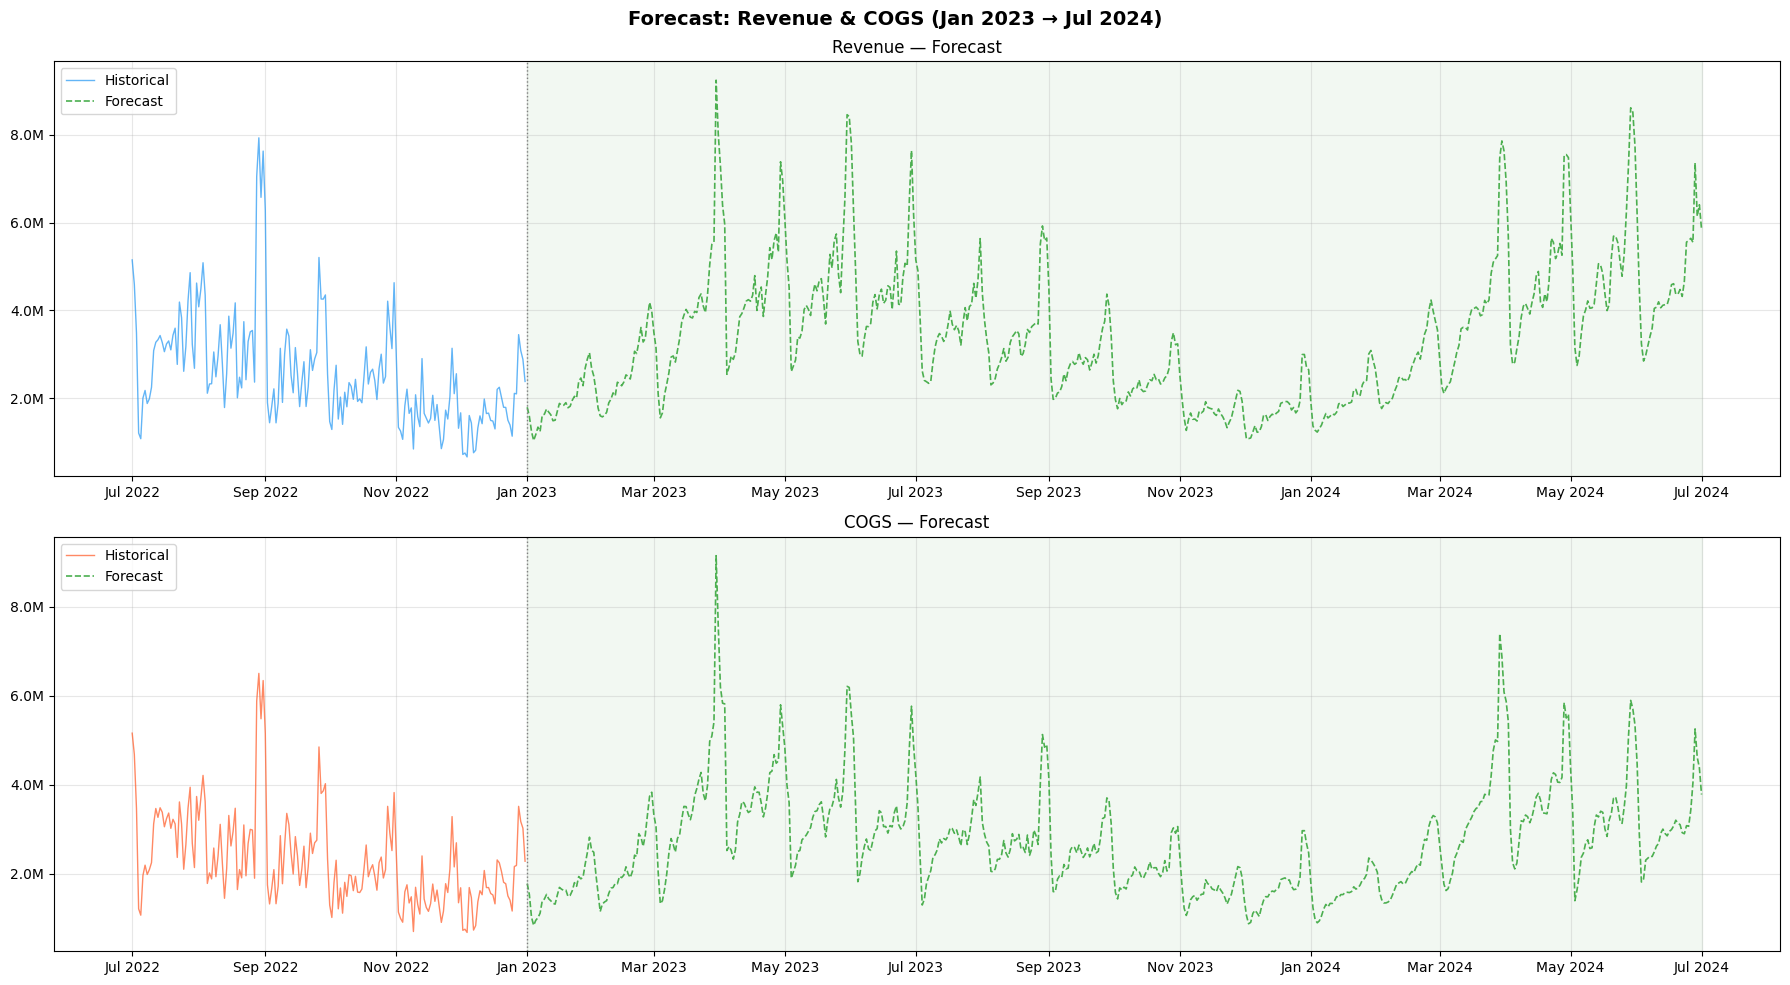


📌 Forecast trông hợp lý nếu tiếp nối xu hướng lịch sử và phản ánh mùa vụ.


In [81]:
# ============================================================
# 4.11.4 — VISUALIZE DỰ BÁO
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Forecast: Revenue & COGS (Jan 2023 → Jul 2024)', fontsize=14, fontweight='bold')

# Lịch sử 6 tháng cuối để context
hist_window = df_sales[df_sales['Date'] >= '2022-07-01'].copy()

for ax, col, pred_arr, color in [
    (axes[0], 'Revenue', pred_revenue, COLOR_REV),
    (axes[1], 'COGS',    pred_cogs,    COLOR_COGS)
]:
    # Lịch sử
    ax.plot(hist_window['Date'], hist_window[col],
            color=color, linewidth=1.0, label='Historical', alpha=0.7)
    
    # Dự báo
    ax.plot(test_dates, pred_arr,
            color=COLOR_PRED, linewidth=1.2, label='Forecast', linestyle='--')
    
    # Shade vùng dự báo
    ax.axvspan(test_dates[0], test_dates[-1], alpha=0.05, color='green')
    ax.axvline(test_dates[0], color='gray', linestyle=':', linewidth=1)
    
    ax.set_title(f'{col} — Forecast')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()
plt.show()
print('\n📌 Forecast trông hợp lý nếu tiếp nối xu hướng lịch sử và phản ánh mùa vụ.')

In [82]:
# ============================================================
# 4.11.5 — TẠO FILE SUBMISSION
# ============================================================
# Mục đích:
# - Tạo file CSV đúng format như sample_submission.csv
# - Cột: Date, Revenue, COGS

df_output = pd.DataFrame({
    'Date'   : test_dates,
    'Revenue': np.round(pred_revenue, 2),
    'COGS'   : np.round(pred_cogs,    2),
})

# Đảm bảo định dạng ngày đúng YYYY-MM-DD
df_output['Date'] = pd.to_datetime(df_output['Date']).dt.strftime('%Y-%m-%d')

# Lưu file
OUTPUT_PATH = 'R2U_submission.csv'
df_output.to_csv(OUTPUT_PATH, index=False)

print('✅ Submission file đã được lưu!')
print(f'📁 File: {OUTPUT_PATH}')
print(f'📊 Shape: {df_output.shape}')
print()
print('=== PREVIEW ===')
print(df_output.head(10).to_string(index=False))
print('...')
print(df_output.tail(5).to_string(index=False))

print('\n=== SUMMARY STATISTICS ===')
print(df_output[['Revenue', 'COGS']].describe())

✅ Submission file đã được lưu!
📁 File: R2U_submission.csv
📊 Shape: (548, 3)

=== PREVIEW ===
      Date      Revenue         COGS
2023-01-01 1,795,197.39 1,777,245.42
2023-01-02 1,588,987.42 1,530,508.04
2023-01-03 1,245,379.62 1,020,787.66
2023-01-04 1,037,363.95   837,250.42
2023-01-05 1,175,313.62   952,666.98
2023-01-06 1,342,920.29 1,008,763.10
2023-01-07 1,243,940.79 1,111,824.16
2023-01-08 1,614,068.67 1,390,025.04
2023-01-09 1,636,336.71 1,429,399.68
2023-01-10 1,755,491.15 1,533,551.17
...
      Date      Revenue         COGS
2024-06-27 5,549,651.52 4,046,231.39
2024-06-28 7,357,068.22 5,254,912.50
2024-06-29 6,141,169.64 4,616,210.42
2024-06-30 6,405,275.15 4,380,118.27
2024-07-01 5,848,364.32 3,779,460.89

=== SUMMARY STATISTICS ===
           Revenue         COGS
count       548.00       548.00
mean  3,404,867.86 2,726,115.56
std   1,534,349.13 1,171,453.60
min   1,037,363.95   837,250.42
25%   2,173,574.80 1,843,680.33
50%   3,195,675.60 2,571,893.17
75%   4,229,436.22 3,3

---

## **Tổng kết Phần 4**

### ✅ Những gì đã làm

| Bước | Mô tả | Kết quả |
|---|---|---|
| **EDA** | Decomposition, ACF/PACF, ADF Test, seasonal patterns | Xác nhận trend tăng + mùa vụ rõ |
| **Feature Engineering** | 7 nhóm features (lag, rolling, calendar, Fourier, holiday, trend, exogenous) | ~60+ features |
| **Baseline** | Naive, Seasonal Naive, Rolling Mean | Benchmark RMSE |
| **LightGBM** | Default + Optuna tuned (50 trials) | Best model |
| **XGBoost** | Default params với early stopping | Diversity cho ensemble |
| **Ensemble** | Optimal weighted blend LightGBM + XGBoost | Thấp hơn từng model đơn lẻ |
| **Recursive Forecast** | 548 ngày multi-step ahead | Tránh look-ahead bias |
| **Business Constraint** | COGS < Revenue | Đảm bảo tính hợp lệ |
| **Submission** | `R2U_submission.csv` | Sẵn sàng nộp Kaggle |

### 🚀 Hướng cải thiện thêm

1. **Tăng N_TRIALS lên 200+** trong Optuna để tìm params tốt hơn
2. **Thêm Prophet model** và blend vào ensemble (đặc biệt tốt cho seasonality)
3. **Target encoding** theo tháng/quý từ dữ liệu lịch sử
4. **Cross-validation 5-fold TimeSeriesSplit** thay vì 1 validation period
5. **Log-transform target** nếu phân phối lệch nhiều → giúp model ổn định hơn
6. **Tích hợp thêm inventory data** (stockout_days, fill_rate) làm feature

---
*Notebook này được viết theo tiêu chuẩn Clean Code với comment đầy đủ bằng tiếng Việt.*  
*Datathon 2026 — The Gridbreakers | VinTelligence — VinUni DS&AI Club*